## Setup and Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

data_path = "/content/drive/MyDrive/SML312Project/data/"
output_path = "/content/drive/MyDrive/SML312Project/outputs/"

print(os.listdir(data_path))

# Load raw data
df = pd.read_csv(data_path + "2015.csv")
acs = pd.read_csv(data_path + "ACSDT5YSPT2015.B08301-Data.csv")
income = pd.read_csv(data_path + "ACSDT5Y2015.B19013-Data.csv")

Mounted at /content/drive
['2015.csv', 'ACSDT5Y2024.B08301-Data.csv', 'ACSDT5YSPT2015.B08301-Column-Metadata.csv', 'ACSDT5YSPT2015.B08301-Data.csv', 'ACSDT5Y2015.B19013-Data.csv', 'ACSDT5Y2015.B19013-Column-Metadata.csv', 'ACSDT5Y2015.B15003-Data.csv', 'ACSDT5Y2015.B23025-Data.csv', 'ACSDT5YSPT2015.B01003-Data.csv', 'ACSDT5YSPT2015.B01003_2026-04-26T215800.zip', 'ACSDT5Y2015.B08303-Data.csv', 'PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260430.csv', 'ACSDT5Y2024.B08301_2026-04-30T103458.zip']


In [2]:
df["MENTHLTH"].value_counts().head(10)

,count
MENTHLTH,
88.0,301076
30.0,22184
2.0,21229
5.0,14749
1.0,13658
3.0,12253
10.0,10684
15.0,9795
4.0,6259


## 2. Cleaning BRFSS Mental Health Data

In [3]:
df["MENTHLTH_CLEAN"] = df["MENTHLTH"].replace({
    88: 0,     # none → 0 days
    77: None,  # don't know → drop
    99: None   # refused → drop
})

/tmp/ipykernel_18126/1528425576.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["MENTHLTH_CLEAN"] = df["MENTHLTH"].replace({


In [4]:
df = df.dropna(subset=["MENTHLTH_CLEAN"])

In [5]:
df["MENTHLTH_CLEAN"].describe() # Clean Mental Health Variable

,MENTHLTH_CLEAN
count,434048.000000
mean,3.316267
std,7.615414
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,30.000000


Mental Health Variable

mean = around 3.3 days of poor mental health per month

median = 0 (most people report no bad days)

heavily skewed -> some people have very high values (up to 30)

In [6]:
[col for col in df.columns if "STATE" in col.upper()]

['_STATE', 'STATERES', 'CSTATE']

In [7]:
df["_STATE"].head() # Location

,_STATE
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [8]:
state_avg = df.groupby("_STATE")["MENTHLTH_CLEAN"].mean()

state_avg.head()

,MENTHLTH_CLEAN
_STATE,
1.0,4.193064
2.0,3.211043
4.0,3.259659
5.0,3.737449
6.0,3.621490


In [9]:
state_avg_sorted = state_avg.sort_values()

state_avg_sorted

,MENTHLTH_CLEAN
_STATE,
46.0,2.472257
38.0,2.540352
31.0,2.625367
27.0,2.730792
15.0,2.770710
19.0,2.806004
20.0,2.833873
11.0,2.883210
56.0,2.911078


In [10]:
state_map = {
    1: "AL", 2: "AK", 4: "AZ", 5: "AR", 6: "CA",
    8: "CO", 9: "CT", 10: "DE", 11: "DC", 12: "FL",
    13: "GA", 15: "HI", 16: "ID", 17: "IL", 18: "IN",
    19: "IA", 20: "KS", 21: "KY", 22: "LA", 23: "ME",
    24: "MD", 25: "MA", 26: "MI", 27: "MN", 28: "MS",
    29: "MO", 30: "MT", 31: "NE", 32: "NV", 33: "NH",
    34: "NJ", 35: "NM", 36: "NY", 37: "NC", 38: "ND",
    39: "OH", 40: "OK", 41: "OR", 42: "PA", 44: "RI",
    45: "SC", 46: "SD", 47: "TN", 48: "TX", 49: "UT",
    50: "VT", 51: "VA", 53: "WA", 54: "WV", 55: "WI",
    56: "WY"
}
state_avg_sorted.index = state_avg_sorted.index.map(state_map)

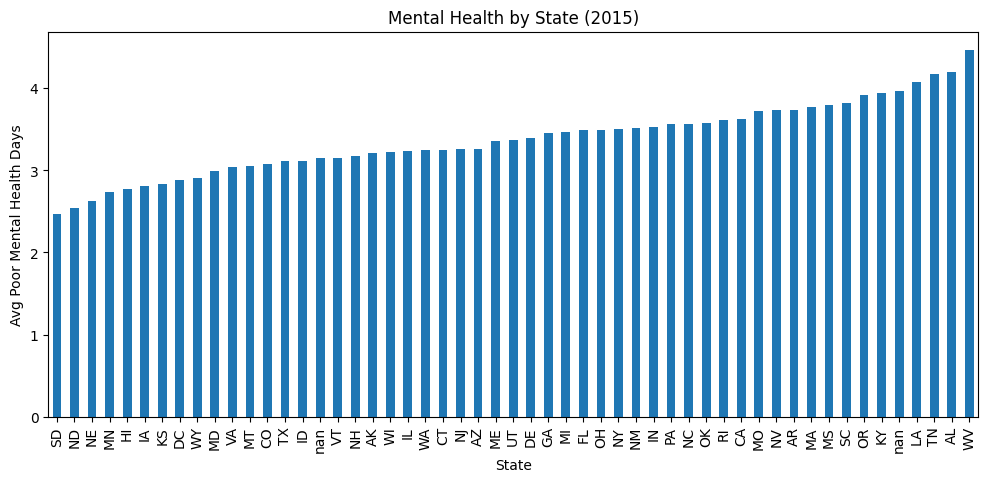

In [ ]:
state_avg_sorted.plot(kind="bar", figsize=(12,5))
plt.xlabel("State")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Mental Health by State (2015)")
plt.show()

## 3. Cleaning ACS Transportation Data

In [11]:
acs = acs[acs["NAME"] != "Geographic Area Name"].copy()

acs["B08301_001E"] = pd.to_numeric(acs["B08301_001E"], errors="coerce")
acs["B08301_002E"] = pd.to_numeric(acs["B08301_002E"], errors="coerce")

acs["car_dependence"] = acs["B08301_002E"] / acs["B08301_001E"]

acs[["NAME", "B08301_001E", "B08301_002E", "car_dependence"]].head()

,NAME,B08301_001E,B08301_002E,car_dependence
1,Alabama,1995472,1888257,0.946271
2,Alaska,356987,287377,0.805007
3,Arizona,2777754,2432283,0.875629
4,Arkansas,1236999,1154708,0.933475
5,California,16869052,14203634,0.841994


In [12]:
# Map BRFSS state codes to names

state_map_full = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas", 6: "California",
    8: "Colorado", 9: "Connecticut", 10: "Delaware", 11: "District of Columbia",
    12: "Florida", 13: "Georgia", 15: "Hawaii", 16: "Idaho", 17: "Illinois",
    18: "Indiana", 19: "Iowa", 20: "Kansas", 21: "Kentucky", 22: "Louisiana",
    23: "Maine", 24: "Maryland", 25: "Massachusetts", 26: "Michigan",
    27: "Minnesota", 28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire", 34: "New Jersey",
    35: "New Mexico", 36: "New York", 37: "North Carolina", 38: "North Dakota",
    39: "Ohio", 40: "Oklahoma", 41: "Oregon", 42: "Pennsylvania",
    44: "Rhode Island", 45: "South Carolina", 46: "South Dakota",
    47: "Tennessee", 48: "Texas", 49: "Utah", 50: "Vermont", 51: "Virginia",
    53: "Washington", 54: "West Virginia", 55: "Wisconsin", 56: "Wyoming"
}

df["state_name"] = df["_STATE"].map(state_map_full)

In [13]:
mental_by_state = (
    df.groupby("state_name", as_index=False)["MENTHLTH_CLEAN"]
      .mean()
      .rename(columns={"MENTHLTH_CLEAN": "avg_mental_health"})
)

mental_by_state.head()

,state_name,avg_mental_health
0,Alabama,4.193064
1,Alaska,3.211043
2,Arizona,3.259659
3,Arkansas,3.737449
4,California,3.621490


In [14]:
acs = acs[acs["NAME"] != "Geographic Area Name"]

## 4. Baseline Analysis

In [15]:
merged = mental_by_state.merge(
    acs[["NAME", "car_dependence"]],
    left_on="state_name",
    right_on="NAME",
    how="inner"
)

merged.head()

,state_name,avg_mental_health,NAME,car_dependence
0,Alabama,4.193064,Alabama,0.946271
1,Alaska,3.211043,Alaska,0.805007
2,Arizona,3.259659,Arizona,0.875629
3,Arkansas,3.737449,Arkansas,0.933475
4,California,3.621490,California,0.841994


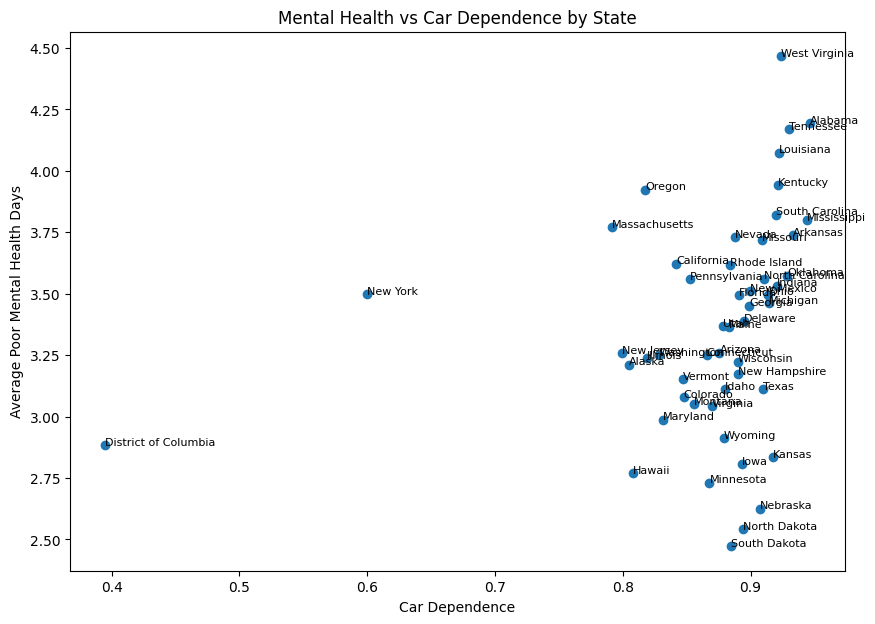

In [16]:
plt.figure(figsize=(10,7))
plt.scatter(merged["car_dependence"], merged["avg_mental_health"])

for i, row in merged.iterrows():
    plt.text(row["car_dependence"], row["avg_mental_health"], row["state_name"], fontsize=8)

plt.xlabel("Car Dependence")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Mental Health vs Car Dependence by State")
plt.show()

There appears to be a weak positive relationship between car dependence and poor mental health outcomes across states, suggesting that higher reliance on automobiles may be associated with worse mental health. The relationship is not strongly linear, indicating that other socioeconomic and environmental factors likely play an important role.

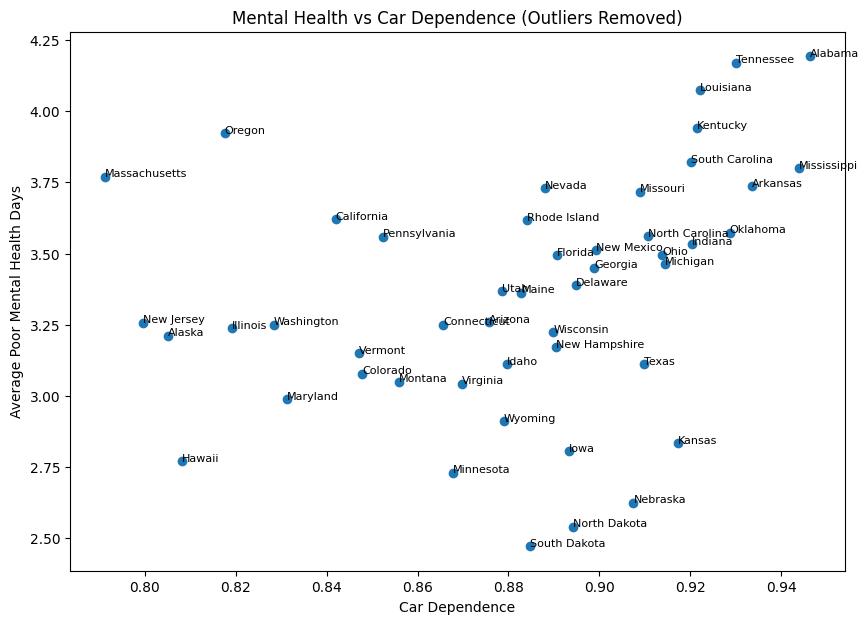

In [17]:
# Remove outliers based on both variables

def remove_outliers(df, cols):
    filtered = df.copy()

    for col in cols:
        Q1 = filtered[col].quantile(0.25)
        Q3 = filtered[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        filtered = filtered[(filtered[col] >= lower) & (filtered[col] <= upper)]

    return filtered

filtered = remove_outliers(merged, ["car_dependence", "avg_mental_health"])

#replot
plt.figure(figsize=(10,7))

plt.scatter(
    filtered["car_dependence"],
    filtered["avg_mental_health"]
)

# Add labels
for _, row in filtered.iterrows():
    plt.text(
        row["car_dependence"],
        row["avg_mental_health"],
        row["state_name"],
        fontsize=8
    )

plt.xlabel("Car Dependence")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Mental Health vs Car Dependence (Outliers Removed)")

plt.show()

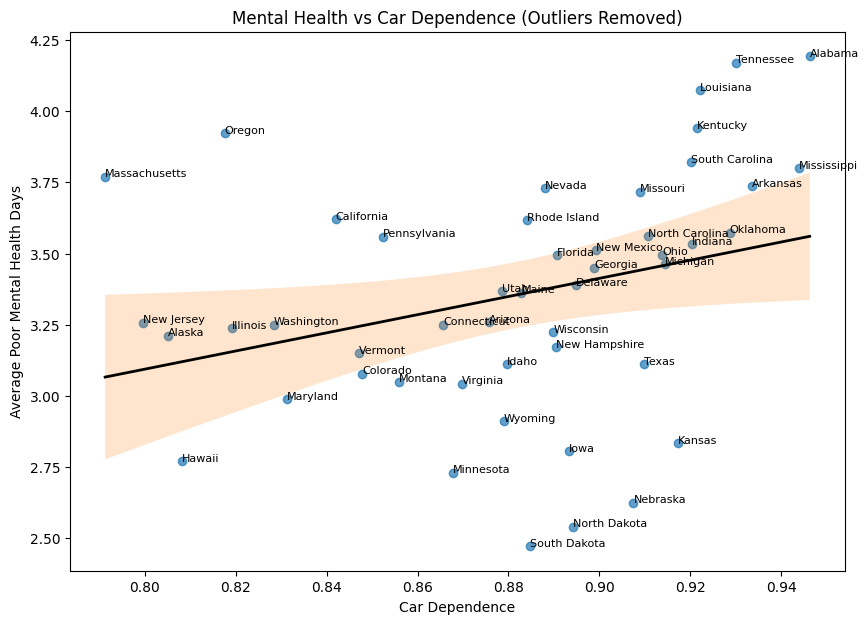

In [18]:
# Add line of best fit
import numpy as np
import statsmodels.api as sm

x = filtered["car_dependence"]
y = filtered["avg_mental_health"]

# Fit regression
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

# Create smooth line
x_vals = np.linspace(x.min(), x.max(), 100)
X_pred = sm.add_constant(x_vals)

pred = model.get_prediction(X_pred).summary_frame()

# Plot
plt.figure(figsize=(10,7))

# Scatter
plt.scatter(x, y, alpha=0.7)

# Labels
for _, row in filtered.iterrows():
    plt.text(row["car_dependence"], row["avg_mental_health"], row["state_name"], fontsize=8)

# Regression line
plt.plot(x_vals, pred["mean"], color="black", linewidth=2)

# Confidence interval
plt.fill_between(
    x_vals,
    pred["mean_ci_lower"],
    pred["mean_ci_upper"],
    alpha=0.2
)

plt.xlabel("Car Dependence")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Mental Health vs Car Dependence (Outliers Removed)")

plt.show()

In [23]:
# Create U.S. choropleth maps: car dependence + mental health

import plotly.graph_objects as go
from plotly.subplots import make_subplots

state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

map_df = merged.copy()
map_df["state_abbrev"] = map_df["state_name"].map(state_abbrev)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=[
        "Car Dependence<br>(% Commuting by Car)",
        "Avg Poor Mental Health Days<br>(Past 30 Days)"
    ]
)

fig.add_trace(
    go.Choropleth(
        locations=map_df["state_abbrev"],
        z=map_df["car_dependence"],
        locationmode="USA-states",
        colorscale="Purples",
        colorbar=dict(
            title="Car<br>Dependence",
            x=0.46
        ),
        marker_line_color="white",
        marker_line_width=0.5
    ),
    row=1, col=1
)

fig.add_trace(
    go.Choropleth(
        locations=map_df["state_abbrev"],
        z=map_df["avg_mental_health"],
        locationmode="USA-states",
        colorscale="Greens",
        colorbar=dict(
            title="Mental<br>Health Days",
            x=1.02
        ),
        marker_line_color="white",
        marker_line_width=0.5
    ),
    row=1, col=2
)

fig.update_geos(
    scope="usa",
    showlakes=True,
    lakecolor="white"
)

fig.update_layout(
    title_text="U.S. Maps by State",
    title_x=0.5,
    height=500,
    width=1000,
    margin=dict(l=20, r=20, t=80, b=20)
)

fig.show()

In [24]:
merged[["car_dependence", "avg_mental_health"]].corr()

,car_dependence,avg_mental_health
car_dependence,1.000000,0.253638
avg_mental_health,0.253638,1.000000


In [25]:
import statsmodels.api as sm

X = merged["car_dependence"]
y = merged["avg_mental_health"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     3.369
Date:                Sat, 09 May 2026   Prob (F-statistic):             0.0725
Time:                        23:51:07   Log-Likelihood:                -28.023
No. Observations:                  51   AIC:                             60.05
Df Residuals:                      49   BIC:                             63.91
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.2680      0.603      3.

In [26]:
model.params

,0
const,2.268011
car_dependence,1.269539


In [27]:
model.pvalues

,0
const,0.000449
car_dependence,0.072506


In [28]:
model.rsquared

np.float64(0.06433243689001589)

The regression results indicate a positive relationship between car dependence and poor mental health outcomes. However, the coefficient is not statistically significant at the 5% level (p = 0.073), and the model explains only a small fraction of the variation (R² = 0.064). This suggests that while there may be an association, other socioeconomic and environmental factors likely play a more substantial role.

## 5. Added Accounting of Controls

In [29]:
# Clean Income Data
income = income[income["NAME"] != "Geographic Area Name"].copy()
income["B19013_001E"] = pd.to_numeric(income["B19013_001E"], errors="coerce")
income_clean = income[["NAME", "B19013_001E"]].rename(
    columns={"B19013_001E": "median_income"}
)
income_clean.head()

,NAME,median_income
1,Alabama,43623
2,Alaska,72515
3,Arizona,50255
4,Arkansas,41371
5,California,61818


In [30]:
# Merge with dataset
merged = merged.merge(
    income_clean,
    left_on="state_name",
    right_on="NAME",
    how="inner"
)

merged.head()

,state_name,avg_mental_health,NAME_x,car_dependence,NAME_y,median_income
0,Alabama,4.193064,Alabama,0.946271,Alabama,43623
1,Alaska,3.211043,Alaska,0.805007,Alaska,72515
2,Arizona,3.259659,Arizona,0.875629,Arizona,50255
3,Arkansas,3.737449,Arkansas,0.933475,Arkansas,41371
4,California,3.621490,California,0.841994,California,61818


In [31]:
# Run regression with income
X = merged[["car_dependence", "median_income"]]
y = merged["avg_mental_health"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     8.008
Date:                Sat, 09 May 2026   Prob (F-statistic):           0.000998
Time:                        23:51:15   Log-Likelihood:                -22.376
No. Observations:                  51   AIC:                             50.75
Df Residuals:                      48   BIC:                             56.55
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              4.9063      0.939      5.

After controlling for median household income, the relationship between car dependence and mental health becomes statistically insignificant, suggesting that the previously observed association was likely driven by underlying income differences. In contrast, income is strongly negatively associated with poor mental health outcomes, indicating that higher-income states tend to experience fewer poor mental health days.

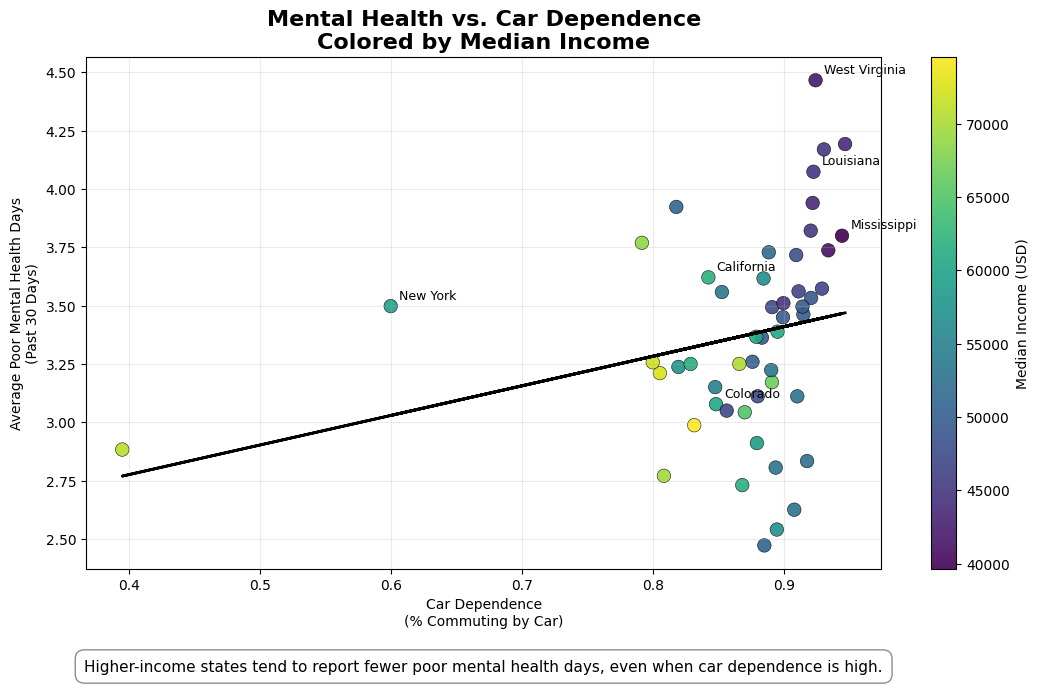

In [33]:
plot_df = merged.dropna(subset=["car_dependence", "avg_mental_health", "median_income"]).copy()

x = plot_df["car_dependence"]
y = plot_df["avg_mental_health"]

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    x, y,
    c=plot_df["median_income"],
    cmap="viridis",
    s=95,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.4
)

m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color="black", linewidth=2)

states_to_label = ["West Virginia", "Mississippi", "Louisiana", "California", "New York", "Colorado"]

for _, row in plot_df.iterrows():
    if row["state_name"] in states_to_label:
        ax.annotate(
            row["state_name"],
            xy=(row["car_dependence"], row["avg_mental_health"]),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=9
        )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Median Income (USD)")

ax.set_title(
    "Mental Health vs. Car Dependence\nColored by Median Income",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Car Dependence\n(% Commuting by Car)")
ax.set_ylabel("Average Poor Mental Health Days\n(Past 30 Days)")

ax.text(
    0.5, -0.20,
    "Higher-income states tend to report fewer poor mental health days, even when car dependence is high.",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="gray", alpha=0.9)
)

ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [34]:
# Load and clean education data
education = pd.read_csv(data_path + "ACSDT5Y2015.B15003-Data.csv")
education.head()
education = education[education["NAME"] != "Geographic Area Name"].copy() # Remove fake header row
edu_cols = ["B15003_001E", "B15003_022E", "B15003_023E", "B15003_024E", "B15003_025E"] # Convert needed columns to numeric

for col in edu_cols:
    education[col] = pd.to_numeric(education[col], errors="coerce")

In [35]:
# Total population age 25+
education["total_25plus"] = education["B15003_001E"]

# Bachelor's degree or higher
education["bachelors_or_higher"] = (
    education["B15003_022E"] +  # Bachelor's degree
    education["B15003_023E"] +  # Master's degree
    education["B15003_024E"] +  # Professional school degree
    education["B15003_025E"]    # Doctorate degree
)

education["pct_bachelors_or_higher"] = (
    education["bachelors_or_higher"] / education["total_25plus"]
)

education_clean = education[["NAME", "pct_bachelors_or_higher"]]

education_clean.head()

,NAME,pct_bachelors_or_higher
1,Alabama,0.235124
2,Alaska,0.279737
3,Arizona,0.274920
4,Arkansas,0.210980
5,California,0.314325


In [36]:
merged = merged.merge(
    education_clean,
    left_on="state_name",
    right_on="NAME",
    how="inner"
)

merged = merged.drop(columns=["NAME"], errors="ignore")

merged.head()

,state_name,avg_mental_health,NAME_x,car_dependence,NAME_y,median_income,pct_bachelors_or_higher
0,Alabama,4.193064,Alabama,0.946271,Alabama,43623,0.235124
1,Alaska,3.211043,Alaska,0.805007,Alaska,72515,0.279737
2,Arizona,3.259659,Arizona,0.875629,Arizona,50255,0.274920
3,Arkansas,3.737449,Arkansas,0.933475,Arkansas,41371,0.210980
4,California,3.621490,California,0.841994,California,61818,0.314325


In [37]:
# Run regression with income and education taken into account
X = merged[["car_dependence", "median_income", "pct_bachelors_or_higher"]]
y = merged["avg_mental_health"]

X = sm.add_constant(X)

education_model = sm.OLS(y, X).fit()

print(education_model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     5.668
Date:                Sat, 09 May 2026   Prob (F-statistic):            0.00213
Time:                        23:51:32   Log-Likelihood:                -21.843
No. Observations:                  51   AIC:                             51.69
Df Residuals:                      47   BIC:                             59.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

After controlling for income and education, car dependence is not significantly associated with mental health. This suggests that the observed relationship is largely explained by socioeconomic factors, particularly income. Education does not add additional explanatory power beyond income, likely due to their correlation. Overall, income appears to be the primary driver of differences in mental health across states.

In [39]:
# Load and clean unemployment data
unemp = pd.read_csv(data_path + "ACSDT5Y2015.B23025-Data.csv")
unemp.head()
unemp = unemp[unemp["NAME"] != "Geographic Area Name"].copy()

# labor force
unemp["B23025_003E"] = pd.to_numeric(unemp["B23025_003E"], errors="coerce")
# unemployment
unemp["B23025_005E"] = pd.to_numeric(unemp["B23025_005E"], errors="coerce")

# create unemployment rate
unemp["unemployment_rate"] = unemp["B23025_005E"] / unemp["B23025_003E"]

# keep only useful columns
unemp_clean = unemp[["NAME", "unemployment_rate"]]

unemp_clean.head()

,NAME,unemployment_rate
1,Alabama,0.092893
2,Alaska,0.081814
3,Arizona,0.089253
4,Arkansas,0.077106
5,California,0.098816


In [40]:
# Merge unemployment into main dataset
merged = merged.merge(
    unemp_clean,
    left_on="state_name",
    right_on="NAME",
    how="inner"
)

# clean up extra NAME column
merged = merged.drop(columns=["NAME"], errors="ignore")

merged.head()

,state_name,avg_mental_health,NAME_x,car_dependence,NAME_y,median_income,pct_bachelors_or_higher,unemployment_rate
0,Alabama,4.193064,Alabama,0.946271,Alabama,43623,0.235124,0.092893
1,Alaska,3.211043,Alaska,0.805007,Alaska,72515,0.279737,0.081814
2,Arizona,3.259659,Arizona,0.875629,Arizona,50255,0.274920,0.089253
3,Arkansas,3.737449,Arkansas,0.933475,Arkansas,41371,0.210980,0.077106
4,California,3.621490,California,0.841994,California,61818,0.314325,0.098816


In [41]:
# Final regression with income, education, and unemployment

X = merged[[
    "car_dependence",
    "median_income",
    "pct_bachelors_or_higher",
    "unemployment_rate"
]]

y = merged["avg_mental_health"]

X = sm.add_constant(X)

final_model = sm.OLS(y, X).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     17.36
Date:                Sat, 09 May 2026   Prob (F-statistic):           9.59e-09
Time:                        23:52:09   Log-Likelihood:                -6.2586
No. Observations:                  51   AIC:                             22.52
Df Residuals:                      46   BIC:                             32.18
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In the full model including car dependence, income, education, and unemployment, only unemployment remains a statistically significant predictor of poor mental health outcomes. Car dependence shows no meaningful relationship with mental health once socioeconomic factors are accounted for. While income and education initially appear relevant, their effects diminish when unemployment is included, suggesting overlapping economic influences. The strong positive relationship between unemployment and poor mental health indicates that labor market conditions play a central role in shaping mental health outcomes across states. Overall, these results suggest that economic instability, rather than transportation patterns, is the primary driver of variation in mental health.

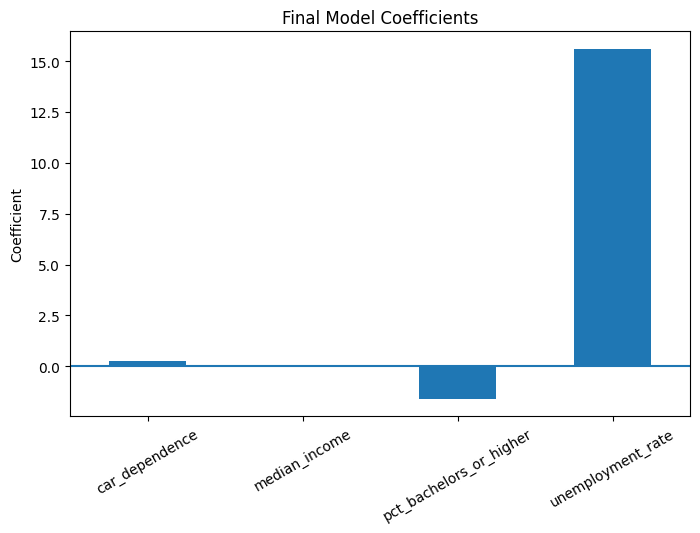

In [42]:
coefs = final_model.params.drop("const")

plt.figure(figsize=(8,5))
coefs.plot(kind="bar")
plt.axhline(0)
plt.ylabel("Coefficient")
plt.title("Final Model Coefficients")
plt.xticks(rotation=30)
plt.show()

The coefficient plot shows that unemployment is the only variable with a large and meaningful effect on mental health. Car dependence has a negligible impact, while income and education show weaker, non-significant relationships. This suggests that labor market conditions, rather than transportation patterns, are the primary factor associated with mental health outcomes.

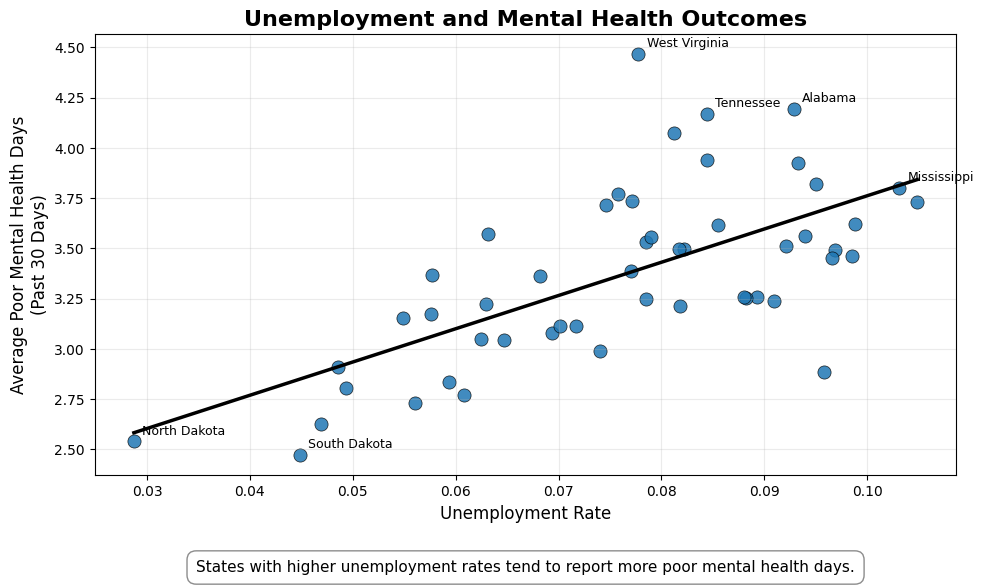

In [43]:
plot_df = merged.dropna(subset=["unemployment_rate", "avg_mental_health"]).copy()

x = plot_df["unemployment_rate"]
y = plot_df["avg_mental_health"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    x,
    y,
    s=90,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5
)

# regression line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

ax.plot(
    x_line,
    y_line,
    linewidth=2.5,
    color="black"
)

states_to_label = [
    "West Virginia",
    "Alabama",
    "Tennessee",
    "Mississippi",
    "South Dakota",
    "North Dakota"
]

for _, row in plot_df.iterrows():
    if row["state_name"] in states_to_label:
        ax.annotate(
            row["state_name"],
            xy=(row["unemployment_rate"], row["avg_mental_health"]),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=9
        )

ax.set_xlabel("Unemployment Rate", fontsize=12)
ax.set_ylabel("Average Poor Mental Health Days\n(Past 30 Days)", fontsize=12)
ax.set_title(
    "Unemployment and Mental Health Outcomes",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    0.5,
    -0.22,
    "States with higher unemployment rates tend to report more poor mental health days.",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="gray", alpha=0.9)
)

ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

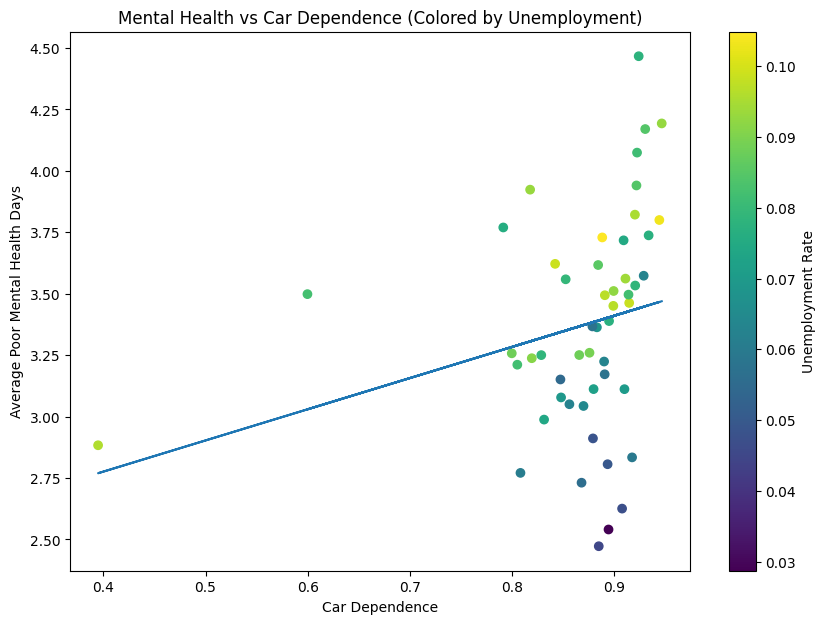

In [44]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    merged["car_dependence"],
    merged["avg_mental_health"],
    c=merged["unemployment_rate"]
)

# regression line
m, b = np.polyfit(
    merged["car_dependence"],
    merged["avg_mental_health"],
    1
)

plt.plot(
    merged["car_dependence"],
    m * merged["car_dependence"] + b
)

# colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Unemployment Rate")

# labels
plt.xlabel("Car Dependence")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Mental Health vs Car Dependence (Colored by Unemployment)")

plt.show()

Although car dependence shows a weak positive relationship with mental health outcomes, the color gradient reveals that unemployment is the dominant factor. States with higher unemployment consistently report worse mental health, regardless of car dependence levels, indicating that economic conditions—not transportation patterns—drive the observed differences.

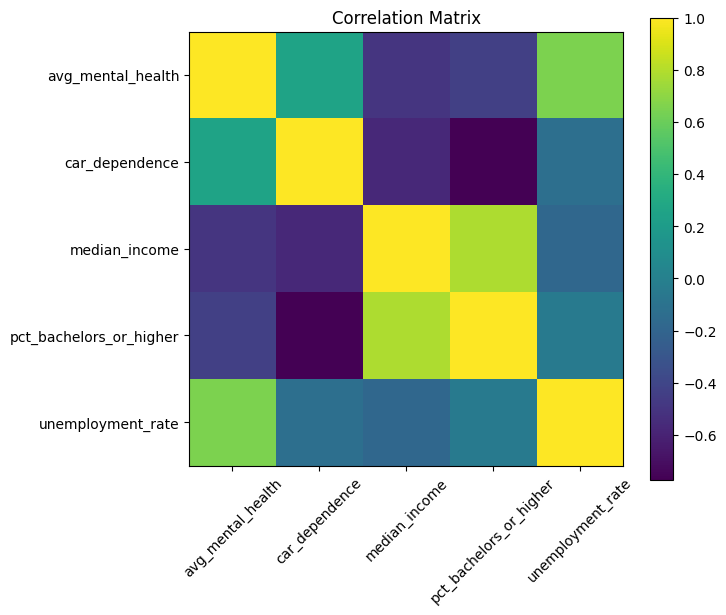

In [45]:
corr = merged[[
    "avg_mental_health",
    "car_dependence",
    "median_income",
    "pct_bachelors_or_higher",
    "unemployment_rate"
]].corr()

plt.figure(figsize=(7,6))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix highlights that unemployment has the strongest positive association with poor mental health outcomes among all variables. In contrast, car dependence shows only a weak correlation with mental health, suggesting a limited direct relationship. Median income and education are both negatively correlated with poor mental health, indicating that higher socioeconomic status is associated with better outcomes. However, the strong positive correlation between income and education suggests substantial overlap between these variables, which helps explain why their individual effects become less significant in the regression models. Overall, this matrix reinforces that unemployment is the most important factor, while also illustrating the multicollinearity present among socioeconomic variables.

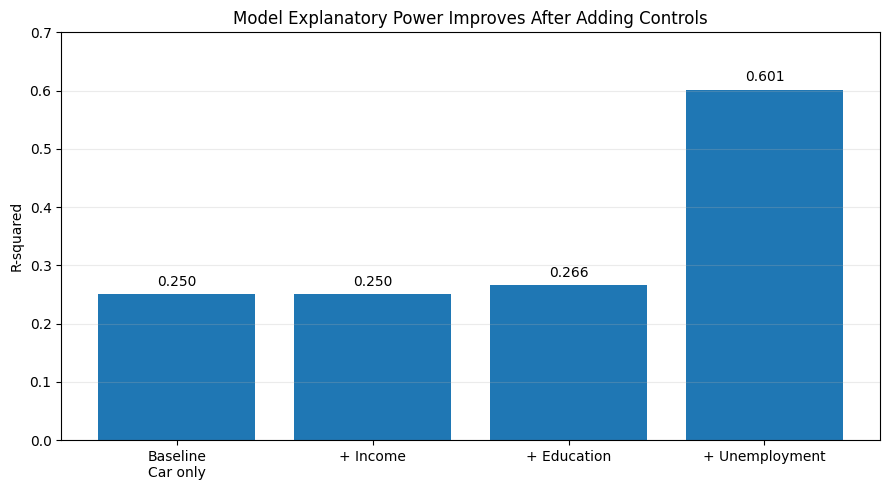

In [46]:
# Model comparison: R-squared across regression specifications

X_income = merged[["car_dependence", "median_income"]]
y = merged["avg_mental_health"]

X_income = sm.add_constant(X_income)
income_model = sm.OLS(y, X_income).fit()

models = [
    model.rsquared,
    income_model.rsquared,
    education_model.rsquared,
    final_model.rsquared
]

labels = [
    "Baseline\nCar only",
    "+ Income",
    "+ Education",
    "+ Unemployment"
]

plt.figure(figsize=(9, 5))

bars = plt.bar(labels, models)

plt.ylabel("R-squared")
plt.title("Model Explanatory Power Improves After Adding Controls")
plt.ylim(0, 0.7)

# Add value labels on bars
for bar, value in zip(bars, models):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

This figure shows how the explanatory power of the model improves as additional control variables are introduced. The baseline model using only car dependence explains very little of the variation in mental health outcomes, and adding income and education results in only modest improvements. However, once unemployment is included, the model’s R-squared increases dramatically, more than doubling its explanatory power. This sharp increase indicates that unemployment captures a substantial portion of the variation in mental health across states that is not explained by the other variables. Overall, the figure reinforces that unemployment is the key factor driving mental health differences, while car dependence contributes little independent explanatory value.

## Public Transit as a Measure of Car Dependence

In [47]:
# Convert all needed ACS transportation columns to numeric

transport_cols = [
    "B08301_001E",  # total commuters
    "B08301_002E",  # car, truck, or van
    "B08301_003E",  # drove alone
    "B08301_004E",  # carpooled
    "B08301_010E"   # public transportation
]

for col in transport_cols:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")

# Create urban planning transportation variables
acs["car_dependence"] = acs["B08301_002E"] / acs["B08301_001E"]
acs["drive_alone_share"] = acs["B08301_003E"] / acs["B08301_001E"]
acs["carpool_share"] = acs["B08301_004E"] / acs["B08301_001E"]
acs["public_transit_share"] = acs["B08301_010E"] / acs["B08301_001E"]

acs[[
    "NAME",
    "car_dependence",
    "drive_alone_share",
    "carpool_share",
    "public_transit_share"
]].head()

,NAME,car_dependence,drive_alone_share,carpool_share,public_transit_share
1,Alabama,0.946271,0.854488,0.091783,0.004236
2,Alaska,0.805007,0.679025,0.125982,0.016384
3,Arizona,0.875629,0.765061,0.110568,0.020889
4,Arkansas,0.933475,0.825608,0.107868,0.004416
5,California,0.841994,0.733897,0.108096,0.052258


In [48]:
transport_clean = acs[[
    "NAME",
    "drive_alone_share",
    "carpool_share",
    "public_transit_share"
]]

merged = merged.merge(
    transport_clean,
    left_on="state_name",
    right_on="NAME",
    how="inner"
)

merged = merged.drop(columns=["NAME"], errors="ignore")

merged.head()

,state_name,avg_mental_health,NAME_x,car_dependence,NAME_y,median_income,pct_bachelors_or_higher,unemployment_rate,drive_alone_share,carpool_share,public_transit_share
0,Alabama,4.193064,Alabama,0.946271,Alabama,43623,0.235124,0.092893,0.854488,0.091783,0.004236
1,Alaska,3.211043,Alaska,0.805007,Alaska,72515,0.279737,0.081814,0.679025,0.125982,0.016384
2,Arizona,3.259659,Arizona,0.875629,Arizona,50255,0.274920,0.089253,0.765061,0.110568,0.020889
3,Arkansas,3.737449,Arkansas,0.933475,Arkansas,41371,0.210980,0.077106,0.825608,0.107868,0.004416
4,California,3.621490,California,0.841994,California,61818,0.314325,0.098816,0.733897,0.108096,0.052258


In [49]:
# Urban planning model: replace car_dependence with more detailed transport structure

X = merged[[
    "drive_alone_share",
    "carpool_share",
    "public_transit_share",
    "median_income",
    "pct_bachelors_or_higher",
    "unemployment_rate"
]]

y = merged["avg_mental_health"]

X = sm.add_constant(X)

urban_model = sm.OLS(y, X).fit()

print(urban_model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     11.95
Date:                Sat, 09 May 2026   Prob (F-statistic):           6.51e-08
Time:                        23:53:13   Log-Likelihood:                -5.0709
No. Observations:                  51   AIC:                             24.14
Df Residuals:                      44   BIC:                             37.66
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [50]:
print("Baseline model R^2:", model.rsquared)
print("Final model (car_dependence) R^2:", final_model.rsquared)
print("Urban model R^2:", urban_model.rsquared)

Baseline model R^2: 0.25017614148222367
Final model (car_dependence) R^2: 0.6014760508401059
Urban model R^2: 0.6196135882071967


Although introducing detailed transportation variables improves model fit slightly, their lack of statistical significance indicates that urban structure alone does not independently drive mental health outcomes. Instead, these results suggest that transportation patterns may reflect deeper underlying economic conditions, rather than acting as direct causal factors. The persistence and strength of unemployment across all model specifications highlight that economic stability is the primary determinant of mental health differences across states, with urban form playing a secondary and more nuanced role.

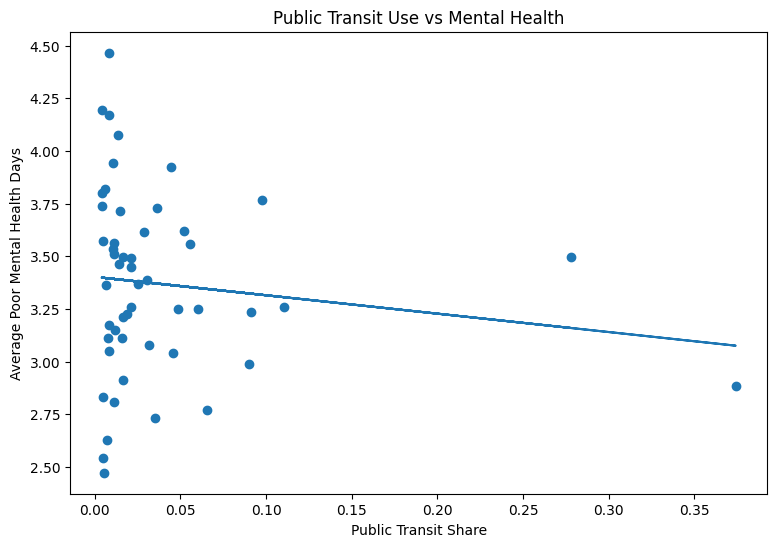

In [51]:
plt.figure(figsize=(9,6))

plt.scatter(
    merged["public_transit_share"],
    merged["avg_mental_health"]
)

m, b = np.polyfit(
    merged["public_transit_share"],
    merged["avg_mental_health"],
    1
)

plt.plot(
    merged["public_transit_share"],
    m * merged["public_transit_share"] + b
)

plt.xlabel("Public Transit Share")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Public Transit Use vs Mental Health")

plt.show()

Although the trend line indicates that higher public transit usage is associated with better mental health outcomes, the relationship is weak and largely driven by a small number of high-transit states. Most states cluster at very low levels of transit use, where variation in mental health remains substantial. This suggests that public transit share alone does not strongly determine mental health, but may instead serve as a proxy for broader urban and socioeconomic conditions that influence well-being.

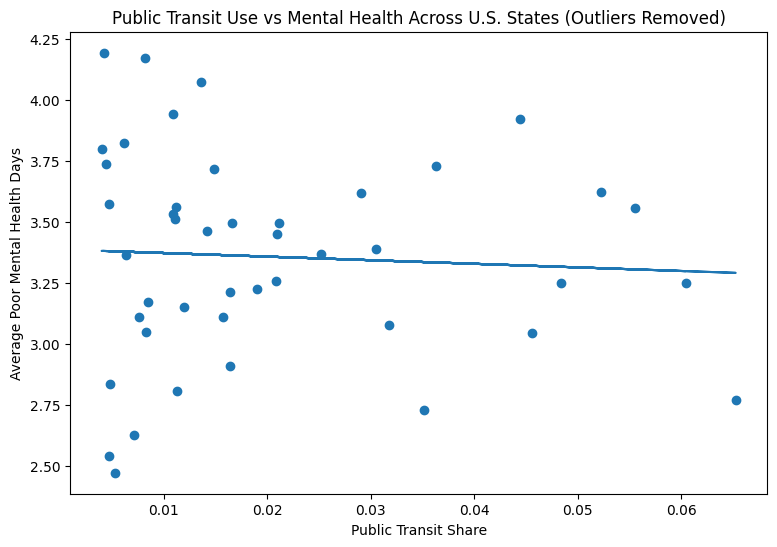

In [54]:
# Copy relevant columns
df = merged[["public_transit_share", "avg_mental_health"]].dropna().copy()

# --- Remove outliers using IQR method ---
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# --- Plot ---
plt.figure(figsize=(9,6))

plt.scatter(
    df_clean["public_transit_share"],
    df_clean["avg_mental_health"]
)


# Regression line
m, b = np.polyfit(
    df_clean["public_transit_share"],
    df_clean["avg_mental_health"],
    1
)

plt.plot(
    df_clean["public_transit_share"],
    m * df_clean["public_transit_share"] + b
)

plt.xlabel("Public Transit Share")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Public Transit Use vs Mental Health Across U.S. States (Outliers Removed)")

plt.show()

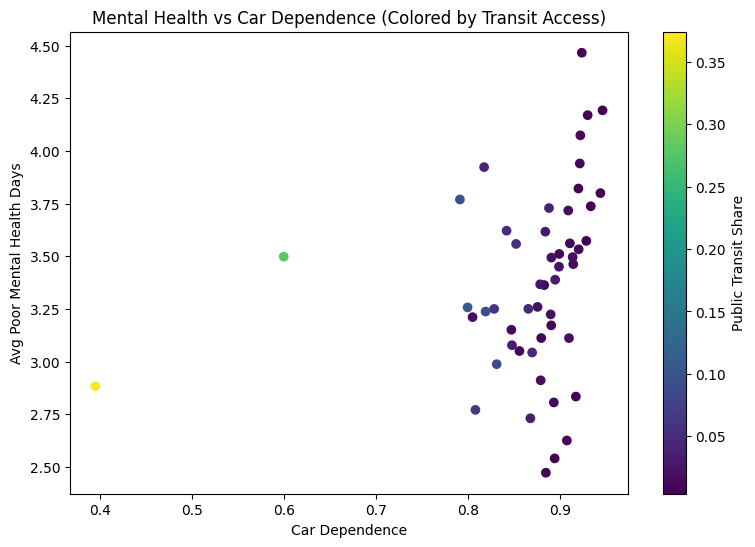

In [55]:
plt.figure(figsize=(9,6))

plt.scatter(
    merged["car_dependence"],
    merged["avg_mental_health"],
    c=merged["public_transit_share"]
)

plt.colorbar(label="Public Transit Share")

plt.xlabel("Car Dependence")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Mental Health vs Car Dependence (Colored by Transit Access)")

plt.show()

This figure illustrates the relationship between car dependence and mental health outcomes, with color representing public transit access. While car dependence alone shows only a weak positive relationship with poor mental health, the color gradient reveals an important underlying pattern. States with higher public transit access (shown in lighter colors) tend to report fewer poor mental health days, even when car dependence levels are similar. In contrast, states with low transit access (darker colors) are more concentrated among higher mental health burden outcomes.

This suggests that the availability of transportation alternatives, rather than car use itself, may be a more meaningful factor in understanding mental health differences across states. In other words, two states can have similar levels of car dependence, but very different mental health outcomes depending on whether residents have access to alternative modes of transportation. This highlights the importance of considering transportation systems more broadly, rather than relying on a single measure like car dependence.

## Urban Sprawl and Population Density

In [56]:
# Load population data
population = pd.read_csv(data_path + "ACSDT5YSPT2015.B01003-Data.csv")

# Clean header row issue
population = population[population["NAME"] != "Geographic Area Name"].copy()

# Convert to numeric
population["B01003_001E"] = pd.to_numeric(population["B01003_001E"], errors="coerce")

# Keep only what we need
population_clean = population[["NAME", "B01003_001E"]].rename(
    columns={"B01003_001E": "population"}
)

# Merge into your main dataset
merged = merged.merge(
    population_clean,
    left_on="state_name",
    right_on="NAME",
    how="inner"
)

# Drop duplicate column
merged = merged.drop(columns=["NAME"], errors="ignore")

# Check
merged.head()

,state_name,avg_mental_health,NAME_x,car_dependence,NAME_y,median_income,pct_bachelors_or_higher,unemployment_rate,drive_alone_share,carpool_share,public_transit_share,population
0,Alabama,4.193064,Alabama,0.946271,Alabama,43623,0.235124,0.092893,0.854488,0.091783,0.004236,4830620
1,Alaska,3.211043,Alaska,0.805007,Alaska,72515,0.279737,0.081814,0.679025,0.125982,0.016384,733375
2,Arizona,3.259659,Arizona,0.875629,Arizona,50255,0.274920,0.089253,0.765061,0.110568,0.020889,6641928
3,Arkansas,3.737449,Arkansas,0.933475,Arkansas,41371,0.210980,0.077106,0.825608,0.107868,0.004416,2958208
4,California,3.621490,California,0.841994,California,61818,0.314325,0.098816,0.733897,0.108096,0.052258,38421464


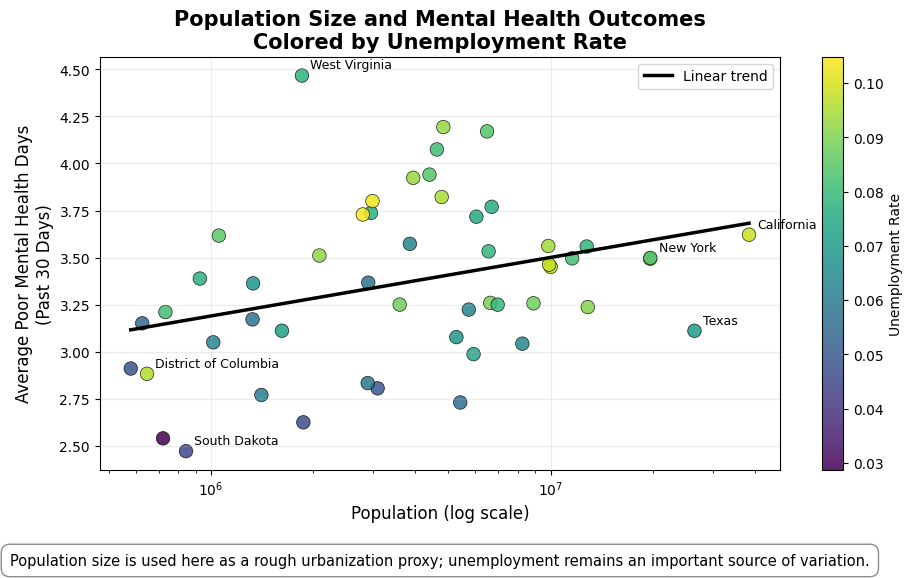

In [57]:
plot_df = merged.dropna(subset=["population", "avg_mental_health", "unemployment_rate"]).copy()

x = plot_df["population"]
y = plot_df["avg_mental_health"]

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    x,
    y,
    c=plot_df["unemployment_rate"],
    s=95,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5
)

# regression line on log(population)
log_x = np.log10(x)
m, b = np.polyfit(log_x, y, 1)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * np.log10(x_line) + b

ax.plot(
    x_line,
    y_line,
    color="black",
    linewidth=2.5,
    label="Linear trend"
)

# log scale
ax.set_xscale("log")

# label selected states
states_to_label = [
    "California",
    "Texas",
    "New York",
    "West Virginia",
    "South Dakota",
    "District of Columbia"
]

for _, row in plot_df.iterrows():
    if row["state_name"] in states_to_label:
        ax.annotate(
            row["state_name"],
            xy=(row["population"], row["avg_mental_health"]),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=9
        )

# colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Unemployment Rate")

# labels and title
ax.set_xlabel("Population (log scale)", fontsize=12)
ax.set_ylabel("Average Poor Mental Health Days\n(Past 30 Days)", fontsize=12)
ax.set_title(
    "Population Size and Mental Health Outcomes\nColored by Unemployment Rate",
    fontsize=15,
    fontweight="bold"
)

# caption box
ax.text(
    0.5,
    -0.23,
    "Population size is used here as a rough urbanization proxy; unemployment remains an important source of variation.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="gray", alpha=0.9)
)

ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [58]:
# State land area in square miles
land_area = {
    "Alabama": 50645, "Alaska": 570641, "Arizona": 113594, "Arkansas": 52035,
    "California": 155779, "Colorado": 103642, "Connecticut": 4842,
    "Delaware": 1949, "Florida": 53625, "Georgia": 57513, "Hawaii": 6423,
    "Idaho": 82643, "Illinois": 55519, "Indiana": 35826, "Iowa": 55857,
    "Kansas": 81759, "Kentucky": 39486, "Louisiana": 43204, "Maine": 30843,
    "Maryland": 9707, "Massachusetts": 7800, "Michigan": 56539,
    "Minnesota": 79627, "Mississippi": 46923, "Missouri": 68742,
    "Montana": 145546, "Nebraska": 76824, "Nevada": 109781,
    "New Hampshire": 8953, "New Jersey": 7354, "New Mexico": 121298,
    "New York": 47126, "North Carolina": 48618, "North Dakota": 68976,
    "Ohio": 40861, "Oklahoma": 68667, "Oregon": 95988,
    "Pennsylvania": 44743, "Rhode Island": 1034, "South Carolina": 30061,
    "South Dakota": 75811, "Tennessee": 41235, "Texas": 261232,
    "Utah": 82170, "Vermont": 9217, "Virginia": 39490,
    "Washington": 66456, "West Virginia": 24038, "Wisconsin": 54158,
    "Wyoming": 97093, "District of Columbia": 61
}

# Add to dataframe
merged["land_area"] = merged["state_name"].map(land_area)

# Create population density
merged["population_density"] = merged["population"] / merged["land_area"]

In [59]:
merged["population_density"] = pd.to_numeric(
    merged["population_density"], errors="coerce"
)

merged = merged.dropna(subset=["population_density"])

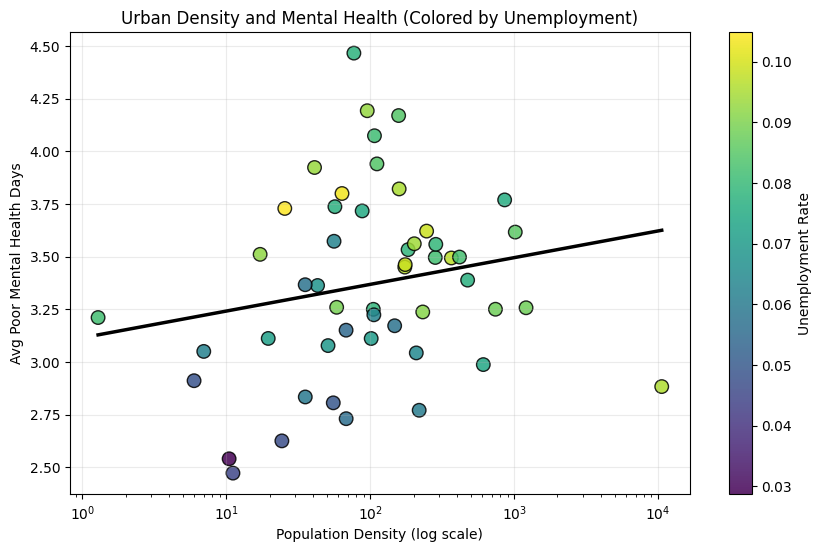

In [60]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged["population_density"],
    merged["avg_mental_health"],
    c=merged["unemployment_rate"],
    s=95,
    edgecolor="black",
    alpha=0.85
)

# regression on log density
log_x = np.log10(merged["population_density"])
y = merged["avg_mental_health"]

m, b = np.polyfit(log_x, y, 1)

x_line = np.linspace(
    merged["population_density"].min(),
    merged["population_density"].max(),
    200
)

y_line = m * np.log10(x_line) + b

plt.plot(x_line, y_line, color="black", linewidth=2.5)

plt.xscale("log")

plt.colorbar(label="Unemployment Rate")

plt.xlabel("Population Density (log scale)")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Urban Density and Mental Health (Colored by Unemployment)")

plt.grid(alpha=0.25)
plt.show()

Lower-density (more sprawling) states tend to exhibit different mental health outcomes than dense urban states, suggesting that the built environment—not just transportation behavior—may shape well-being.

## Urban vs Suburban vs Rural Groups

In [61]:
# Create 3 groups: low (sprawl), medium, high (urban)
merged["density_group"] = pd.qcut(
    merged["population_density"],
    q=3,
    labels=["Low Density (Sprawl)", "Medium Density", "High Density (Urban)"]
)

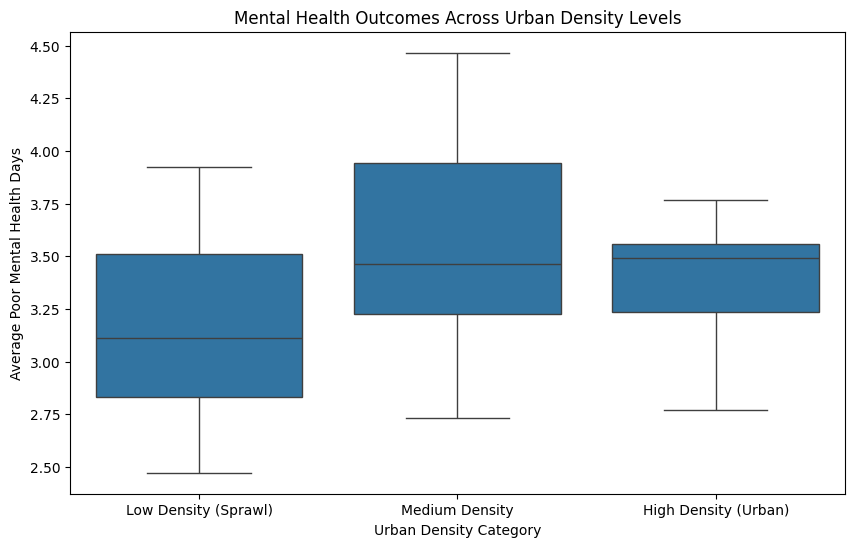

In [62]:
import seaborn as sns
# Make a box plot
plt.figure(figsize=(10,6))

sns.boxplot(
    x="density_group",
    y="avg_mental_health",
    data=merged
)

plt.xlabel("Urban Density Category")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Mental Health Outcomes Across Urban Density Levels")

plt.show()

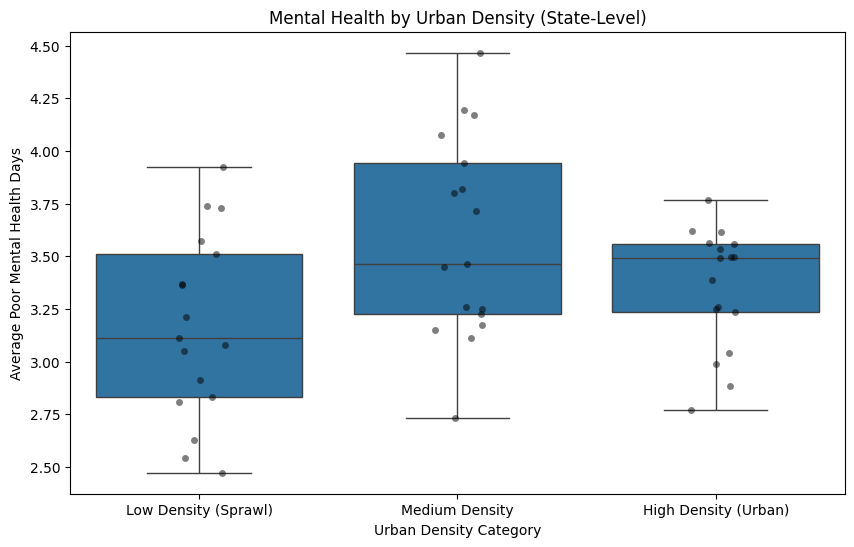

In [63]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="density_group",
    y="avg_mental_health",
    data=merged,
    showfliers=False
)

sns.stripplot(
    x="density_group",
    y="avg_mental_health",
    data=merged,
    color="black",
    alpha=0.5,
    jitter=True
)

plt.xlabel("Urban Density Category")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Mental Health by Urban Density (State-Level)")

plt.show()

This figure compares mental health outcomes across states grouped by population density, serving as a proxy for urban versus suburban and rural environments. While there is some variation across groups, the differences are not sharply distinct, suggesting that density alone does not strongly determine mental health outcomes. However, lower-density (more sprawling) states appear to exhibit slightly higher variability and, in some cases, worse outcomes. This supports the idea that urban form may play a role in shaping well-being, but likely operates alongside stronger economic factors such as unemployment.

In [64]:
merged["density_unemployment"] = (
    np.log(merged["population_density"]) * merged["unemployment_rate"]
)

In [65]:
X = merged[[
    "population_density",
    "unemployment_rate",
    "density_unemployment",
    "median_income",
    "pct_bachelors_or_higher"
]]

y = merged["avg_mental_health"]

X = sm.add_constant(X)

interaction_model = sm.OLS(y, X).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     15.11
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.06e-08
Time:                        02:15:24   Log-Likelihood:                -4.5957
No. Observations:                  51   AIC:                             21.19
Df Residuals:                      45   BIC:                             32.78
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

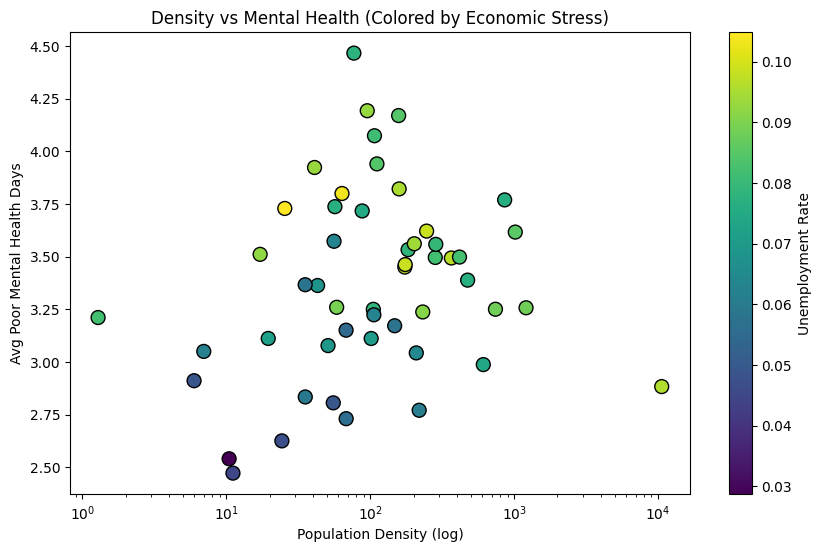

In [66]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged["population_density"],
    merged["avg_mental_health"],
    c=merged["unemployment_rate"],
    s=100,
    edgecolor="black"
)

plt.xscale("log")

plt.colorbar(label="Unemployment Rate")

plt.xlabel("Population Density (log)")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Density vs Mental Health (Colored by Economic Stress)")

plt.show()

There is no clear direct relationship between population density and mental health, as outcomes vary widely across all density levels. However, the color gradient shows that higher unemployment is consistently associated with worse mental health, regardless of density. This suggests that economic stress is a more important driver than urban form alone, with density playing at most a secondary, context-dependent role.

In [67]:
high_unemp = merged[merged["unemployment_rate"] > merged["unemployment_rate"].median()]
low_unemp = merged[merged["unemployment_rate"] <= merged["unemployment_rate"].median()]

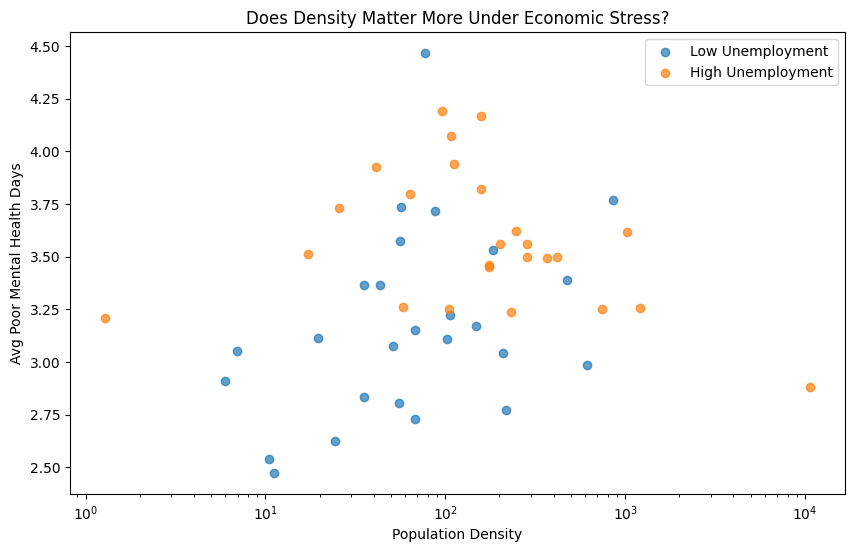

In [68]:
plt.figure(figsize=(10,6))

plt.scatter(
    low_unemp["population_density"],
    low_unemp["avg_mental_health"],
    label="Low Unemployment",
    alpha=0.7
)

plt.scatter(
    high_unemp["population_density"],
    high_unemp["avg_mental_health"],
    label="High Unemployment",
    alpha=0.7
)

plt.xscale("log")

plt.legend()
plt.xlabel("Population Density")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Does Density Matter More Under Economic Stress?")

plt.show()

There is no strong overall relationship between population density and mental health. However, states with higher unemployment consistently report worse mental health outcomes across all density levels. This suggests that economic conditions matter more than density alone.

Additionally, variation is greater in low-unemployment states, indicating that density may play a role only when economic conditions are stable. Overall, the impact of urban density appears conditional on broader socioeconomic context rather than independently significant.

## Descriptive Statistics for Final Variables

In [69]:
analysis_vars = [
    "avg_mental_health",
    "car_dependence",
    "drive_alone_share",
    "carpool_share",
    "public_transit_share",
    "population_density",
    "median_income",
    "pct_bachelors_or_higher",
    "unemployment_rate"
]

summary_stats = merged[analysis_vars].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
avg_mental_health,51.0,3.368778,0.437655,2.472257,3.094646,3.366886,3.619135,4.466564
car_dependence,51.0,0.867061,0.087438,0.394909,0.850062,0.888087,0.912283,0.946271
drive_alone_share,51.0,0.771349,0.082983,0.337425,0.752845,0.795922,0.818954,0.854488
carpool_share,51.0,0.095712,0.013742,0.057484,0.087674,0.094646,0.102883,0.140823
public_transit_share,51.0,0.038262,0.065068,0.004000,0.008244,0.016384,0.040378,0.374117
population_density,51.0,402.691536,1481.830892,1.285178,47.013239,105.114121,225.413826,10614.491803
median_income,51.0,54636.098039,9157.173995,39665.000000,47545.000000,52997.000000,60678.000000,74551.000000
pct_bachelors_or_higher,51.0,0.295149,0.060557,0.191564,0.259796,0.283604,0.320954,0.545767
unemployment_rate,51.0,0.076259,0.017207,0.028719,0.063077,0.078465,0.090074,0.104866


The descriptive statistics reveal substantial variation across states in both transportation structure and socioeconomic conditions. Car dependence is consistently high, with a mean of approximately 87%, indicating that most states are heavily reliant on automobiles. In contrast, public transit usage is both low and highly skewed, with a mean below 4% and a maximum driven by a few dense, transit-oriented states. Population density exhibits extreme variation, spanning several orders of magnitude, which justifies the use of a log transformation in subsequent analysis. Socioeconomic variables such as income, education, and unemployment show moderate dispersion, suggesting meaningful cross-state differences. Overall, these patterns highlight the dominance of car-oriented infrastructure in the U.S. while also indicating the presence of a small set of more urban, transit-accessible environments, which may play a distinct role in shaping mental health outcomes.

In [70]:
# Correlation with mental health (sorted)

corr_with_y = merged[analysis_vars].corr()["avg_mental_health"].sort_values()

corr_with_y

,avg_mental_health
median_income,-0.499065
pct_bachelors_or_higher,-0.435950
population_density,-0.139214
public_transit_share,-0.129806
carpool_share,-0.000207
car_dependence,0.253638
drive_alone_share,0.267290
unemployment_rate,0.650221
avg_mental_health,1.000000


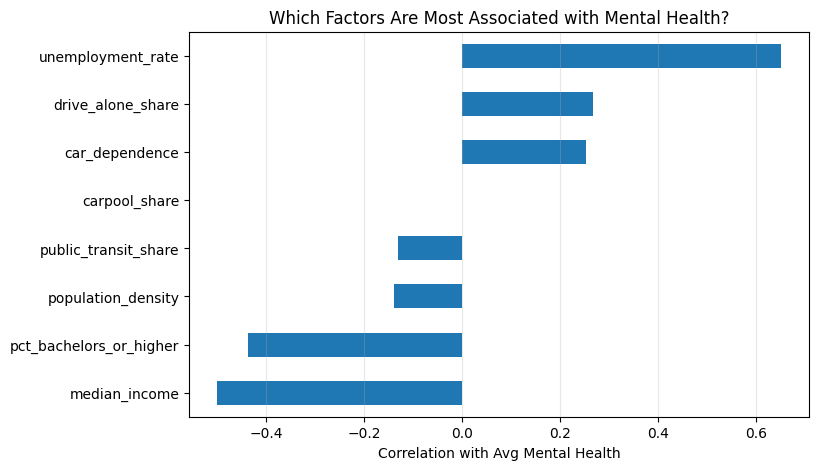

In [71]:
plt.figure(figsize=(8,5))

corr_with_y.drop("avg_mental_health").plot(kind="barh")

plt.xlabel("Correlation with Avg Mental Health")
plt.title("Which Factors Are Most Associated with Mental Health?")
plt.grid(axis="x", alpha=0.3)

plt.show()

<Axes: title={'center': 'Which Factors Are Most Associated with Mental Health?'}>

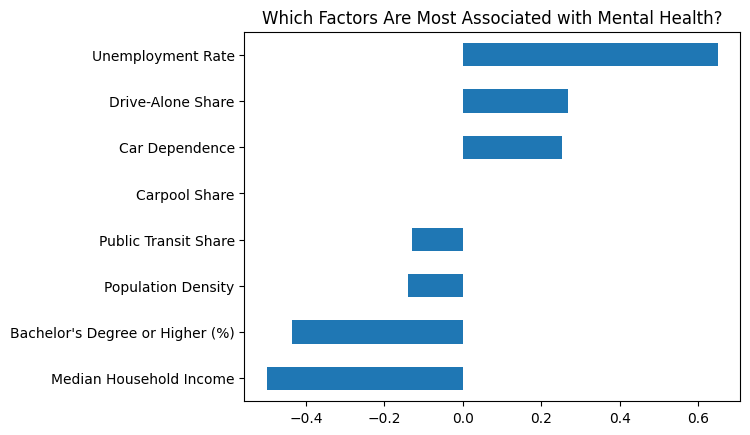

In [72]:
# Rename variables for plotting
pretty_names = {
    "unemployment_rate": "Unemployment Rate",
    "drive_alone_share": "Drive-Alone Share",
    "car_dependence": "Car Dependence",
    "carpool_share": "Carpool Share",
    "public_transit_share": "Public Transit Share",
    "population_density": "Population Density",
    "pct_bachelors_or_higher": "Bachelor's Degree or Higher (%)",
    "median_income": "Median Household Income"
}

corr_with_y_renamed = corr_with_y.rename(index=pretty_names)

plt.xlabel("Correlation with Avg Mental Health")
plt.title("Which Factors Are Most Associated with Mental Health?")
plt.grid(axis="x", alpha=0.3)


corr_with_y_renamed.drop("avg_mental_health").plot(kind="barh")

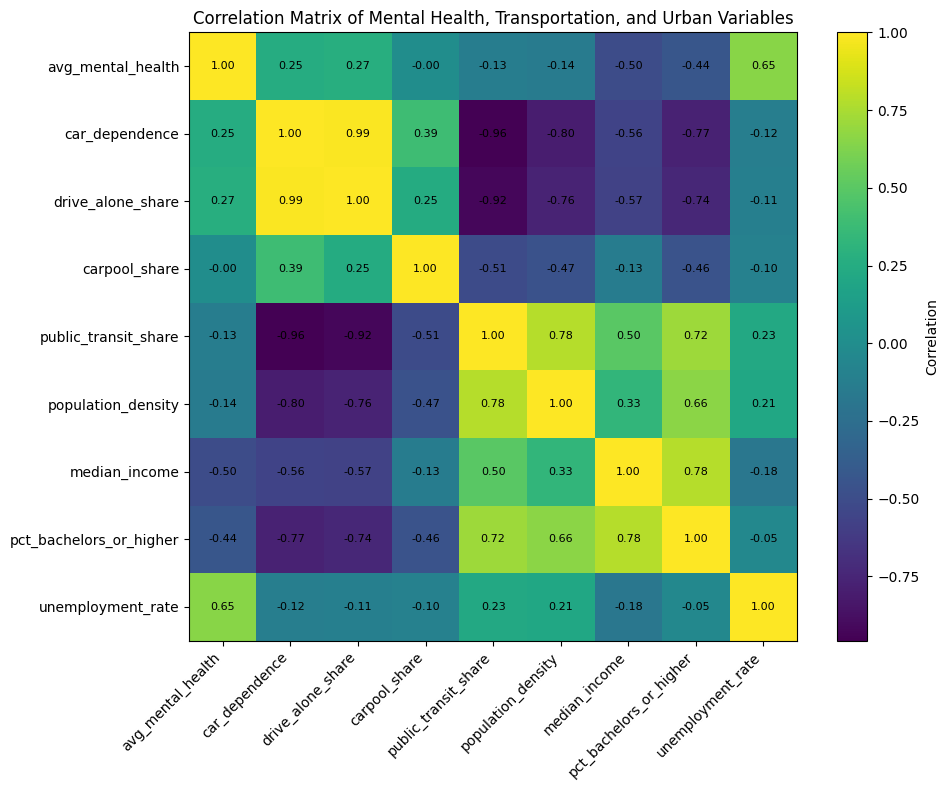

In [73]:
# Pairwise correlations among transportation, urban structure, and socioeconomic variables

corr = merged[analysis_vars].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Matrix of Mental Health, Transportation, and Urban Variables")
plt.tight_layout()
plt.show()

The correlation matrix shows that mental health is most strongly related to unemployment (≈ 0.65), suggesting economic stress is the key driver of worse outcomes. In contrast, urban planning variables like car dependence, transit use, and density have weak direct relationships with mental health. However, these variables are highly correlated with each other, indicating they capture a shared “urban vs. sprawl” structure. Overall, this suggests that while urban form varies significantly across states, economic conditions matter more for mental health outcomes.

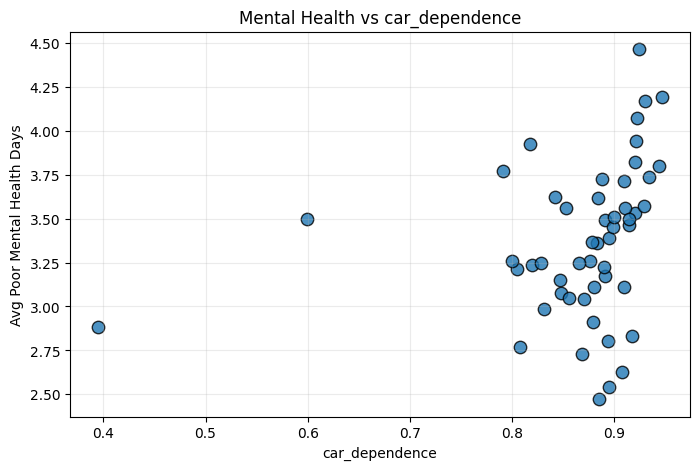

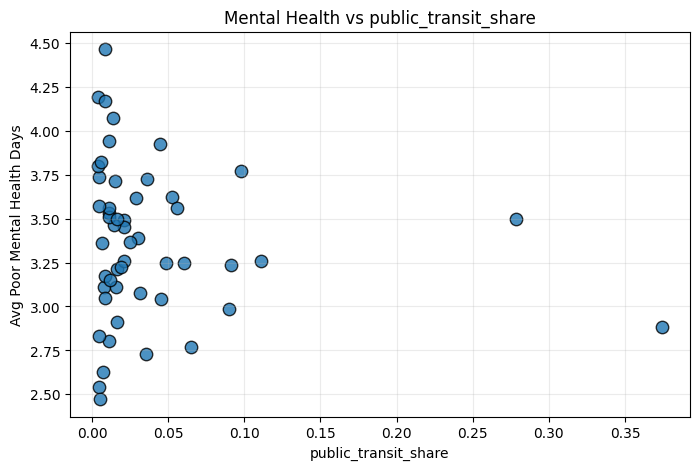

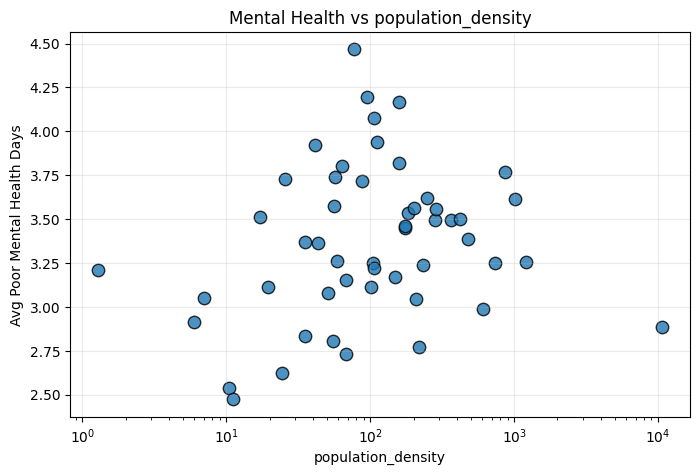

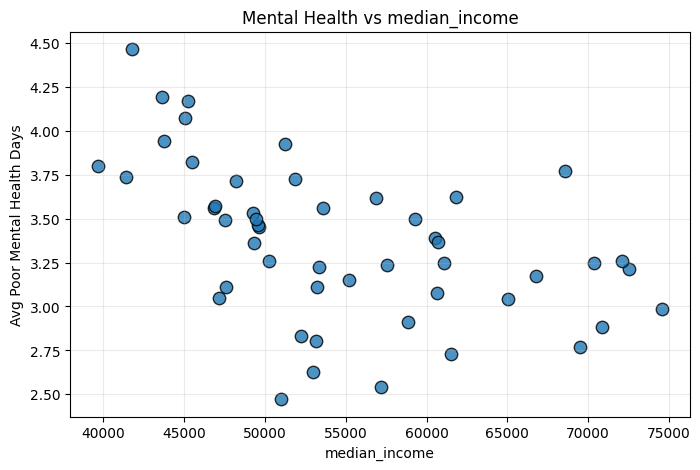

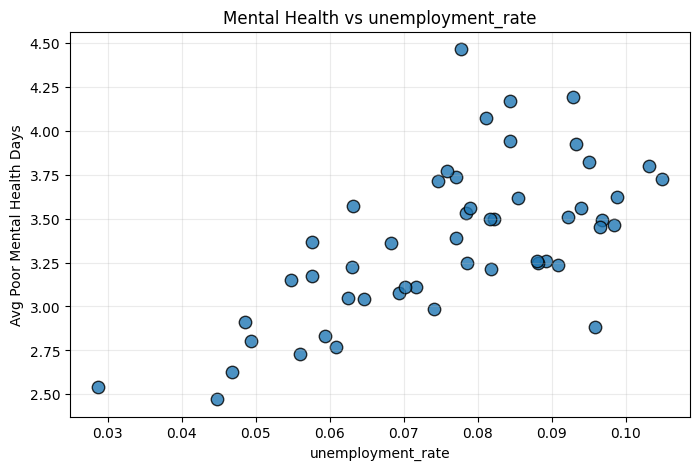

In [74]:
# Pairwise relationships with mental health

for var in [
    "car_dependence",
    "public_transit_share",
    "population_density",
    "median_income",
    "unemployment_rate"
]:
    plt.figure(figsize=(8,5))

    plt.scatter(
        merged[var],
        merged["avg_mental_health"],
        s=80,
        alpha=0.8,
        edgecolor="black"
    )

    if var == "population_density":
        plt.xscale("log")

    plt.xlabel(var)
    plt.ylabel("Avg Poor Mental Health Days")
    plt.title(f"Mental Health vs {var}")
    plt.grid(alpha=0.25)
    plt.show()

## 10. Random Forest

In [77]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np

merged["log_density"] = np.log(merged["population_density"])
# Features
X = merged[
    [
        "log_density",
        "car_dependence",
        "public_transit_share",
        "median_income",
        "pct_bachelors_or_higher",
        "unemployment_rate"
    ]
]

y = merged["avg_mental_health"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [78]:
# Feature Importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values()

importance

,0
log_density,0.033108
public_transit_share,0.041607
pct_bachelors_or_higher,0.071406
car_dependence,0.103751
median_income,0.276665
unemployment_rate,0.473464


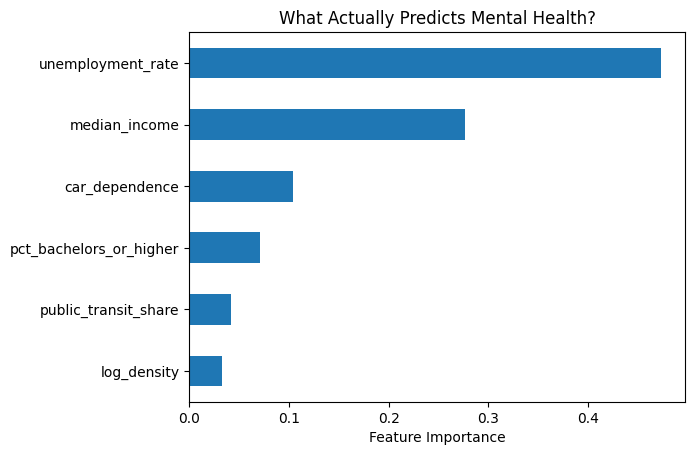

In [79]:
# Visualization
importance.plot(kind="barh")

plt.xlabel("Feature Importance")
plt.title("What Actually Predicts Mental Health?")
plt.show()

The Random Forest results reinforce the earlier regression findings by showing that unemployment is by far the most important predictor of mental health outcomes, followed by median income. In contrast, urban form variables such as car dependence, public transit use, and population density have relatively low importance. This suggests that even when allowing for non-linear relationships, economic conditions dominate in explaining variation in mental health across states. While aspects of the built environment are correlated with each other, they do not appear to play a major independent role in predicting mental health outcomes in this dataset.

These results suggest that while urban form varies significantly across states, it is not the primary driver of mental health outcomes. Instead, economic conditions—particularly unemployment—consistently emerge as the dominant factor, indicating that the effects of the built environment may be secondary to broader socioeconomic context.

## Factors Driving Car Deendence/Urban Sprawl

In [81]:
y = merged["car_dependence"]
X = merged[
    [
        "median_income",
        "pct_bachelors_or_higher",
        "unemployment_rate",
        "log_density"
    ]
]

X = sm.add_constant(X)

car_model = sm.OLS(y, X).fit()

print(car_model.summary())

                            OLS Regression Results                            
Dep. Variable:         car_dependence   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     19.18
Date:                Sun, 10 May 2026   Prob (F-statistic):           2.43e-09
Time:                        02:16:11   Log-Likelihood:                 77.436
No. Observations:                  51   AIC:                            -144.9
Df Residuals:                      46   BIC:                            -135.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

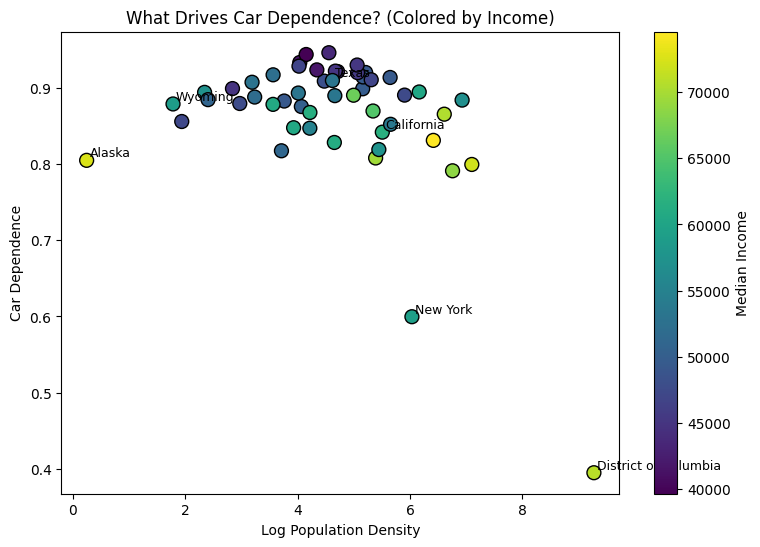

In [82]:
plt.figure(figsize=(9,6))

plt.scatter(
    merged["log_density"],
    merged["car_dependence"],
    c=merged["median_income"],
    s=100,
    edgecolor="black"
)

# Add colorbar
plt.colorbar(label="Median Income")

# Label ONLY key states (outliers / interesting ones)
key_states = ["New York", "California", "Texas", "District of Columbia", "Wyoming", "Alaska"]

for _, row in merged.iterrows():
    if row["state_name"] in key_states:
        plt.text(
            row["log_density"] + 0.05,
            row["car_dependence"] + 0.005,
            row["state_name"],
            fontsize=9
        )

plt.xlabel("Log Population Density")
plt.ylabel("Car Dependence")
plt.title("What Drives Car Dependence? (Colored by Income)")

plt.show()

Car dependence remains high across nearly all states, with only a slight decrease in more densely populated areas. This suggests that population density alone is insufficient to reduce reliance on cars. While higher-income states show slightly lower car dependence, the overall pattern indicates that structural factors beyond density—such as infrastructure and transit availability—play a critical role in shaping transportation behavior.

In [83]:
# Identify outliers in car dependence
Q1 = merged["car_dependence"].quantile(0.25)
Q3 = merged["car_dependence"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

filtered = merged[
    (merged["car_dependence"] >= lower) &
    (merged["car_dependence"] <= upper)
]

In [84]:
filtered = filtered[
    filtered["log_density"] < 8   # removes DC-level extremes
]

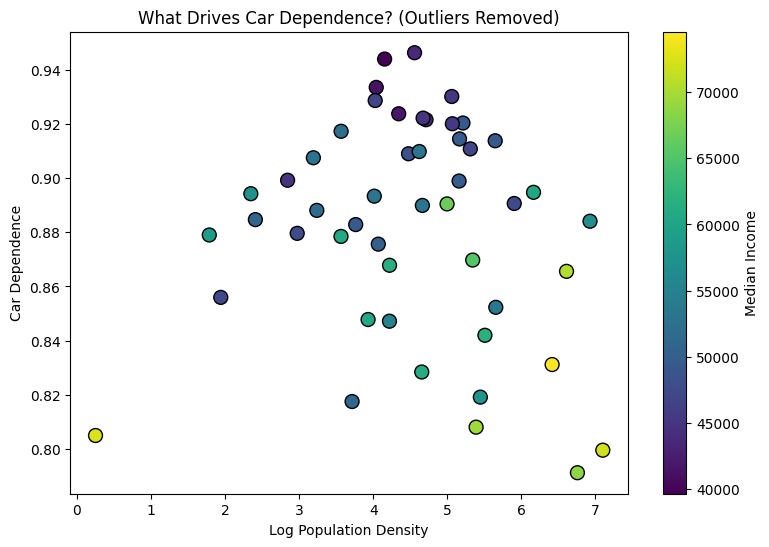

In [85]:
# Replot without outliers
plt.figure(figsize=(9,6))

plt.scatter(
    filtered["log_density"],
    filtered["car_dependence"],
    c=filtered["median_income"],
    s=100,
    edgecolor="black"
)

plt.colorbar(label="Median Income")

plt.xlabel("Log Population Density")
plt.ylabel("Car Dependence")
plt.title("What Drives Car Dependence? (Outliers Removed)")

plt.show()

When extreme urban outliers are removed, the relationship between density and car dependence becomes more stable but remains relatively weak, reinforcing the idea that most U.S. states are structurally car-dependent regardless of density.

<Figure size 800x500 with 0 Axes>

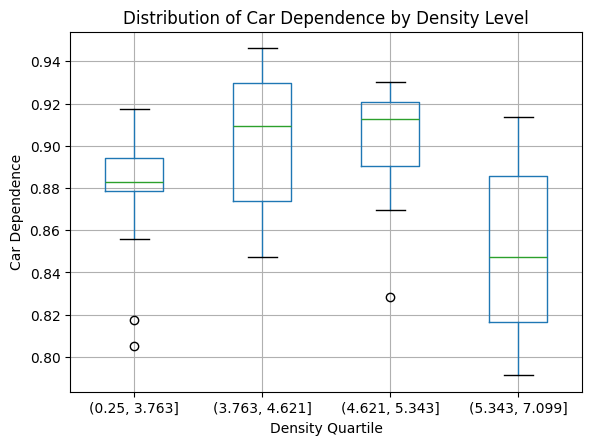

In [86]:
# Box Plot
plt.figure(figsize=(8,5))

filtered["density_bin"] = pd.qcut(filtered["log_density"], q=4)

filtered.boxplot(column="car_dependence", by="density_bin")

plt.title("Distribution of Car Dependence by Density Level")
plt.suptitle("")
plt.xlabel("Density Quartile")
plt.ylabel("Car Dependence")

plt.show()

Car dependence remains high across all density levels, with only a modest decline in the highest-density quartile. However, the distribution becomes more dispersed at higher densities, indicating that while dense environments can support lower car dependence, they do not consistently do so. This suggests that population density alone is insufficient to reduce reliance on cars, and that additional factors—such as transit infrastructure, land use patterns, and policy—likely play a critical role in shaping transportation behavior.

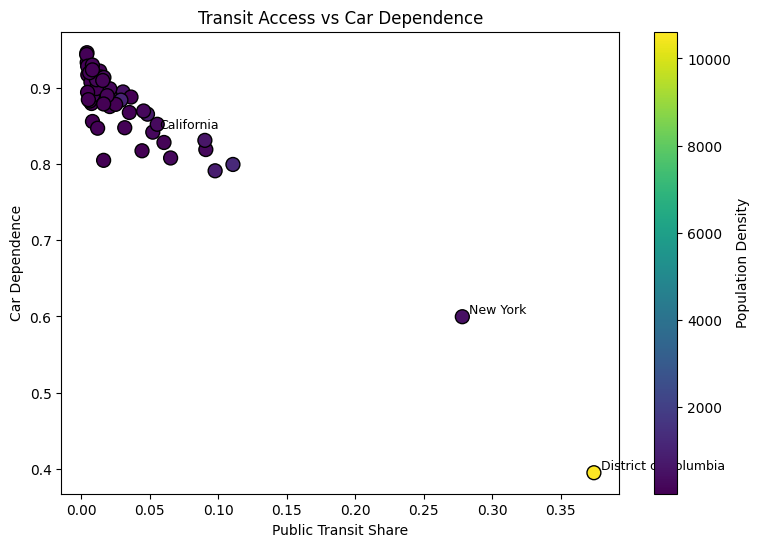

In [87]:
# Transit vs car dependence
plt.figure(figsize=(9,6))

plt.scatter(
    merged["public_transit_share"],
    merged["car_dependence"],
    c=merged["population_density"],
    s=100,
    edgecolor="black"
)

plt.colorbar(label="Population Density")

key_states = ["District of Columbia", "New York", "California"]

for _, row in merged.iterrows():
    if row["state_name"] in key_states:
        plt.text(
            row["public_transit_share"] + 0.005,
            row["car_dependence"] + 0.005,
            row["state_name"],
            fontsize=9
        )

plt.xlabel("Public Transit Share")
plt.ylabel("Car Dependence")
plt.title("Transit Access vs Car Dependence")

plt.show()

Public transit share and car dependence are almost inverse. Most states have very low transit use and very high car dependence, clustered in the upper-left. The few places with much higher transit share have much lower car dependence.

Car dependence is not just about population density; it is strongly shaped by access to transportation alternatives. Most states remain highly car-dependent because public transit share is extremely low, while the few dense, transit-rich places show substantially lower dependence on cars.

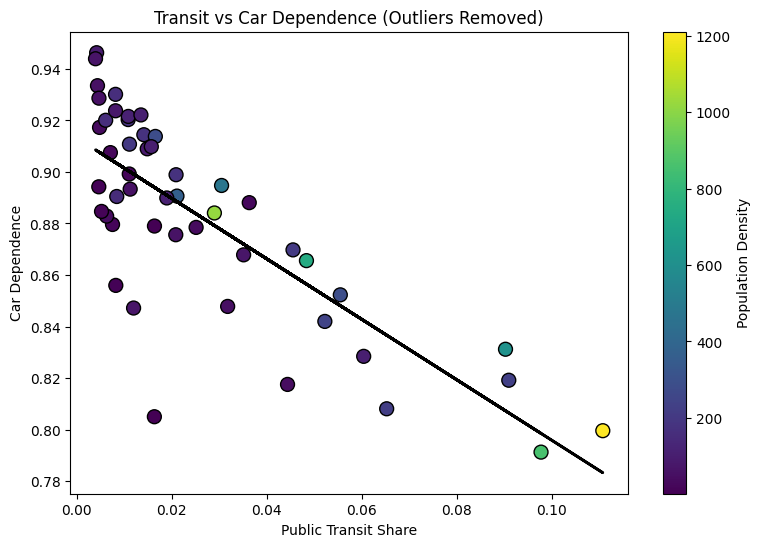

In [88]:
# Remove outliers
filtered = merged[
    (merged["public_transit_share"] < 0.15) &   # removes DC/NY
    (merged["car_dependence"] > 0.75)           # removes extreme low car dependence
]
plt.figure(figsize=(9,6))

plt.scatter(
    filtered["public_transit_share"],
    filtered["car_dependence"],
    c=filtered["population_density"],
    s=100,
    edgecolor="black"
)

plt.colorbar(label="Population Density")

plt.xlabel("Public Transit Share")
plt.ylabel("Car Dependence")
plt.title("Transit vs Car Dependence (Outliers Removed)")

m, b = np.polyfit(
    filtered["public_transit_share"],
    filtered["car_dependence"],
    1
)

plt.plot(
    filtered["public_transit_share"],
    m * filtered["public_transit_share"] + b,
    color="black",
    linewidth=2
)

plt.show()

After removing extreme urban outliers, a clearer negative relationship emerges between public transit use and car dependence. States with higher transit share tend to exhibit lower reliance on cars, suggesting that transit availability plays an important role in shaping transportation behavior. However, the magnitude of this effect remains limited: even among states with relatively higher transit use, car dependence remains high overall. This indicates that while transit access can reduce car reliance, it is not sufficient on its own to fundamentally shift transportation patterns at the state level.

## Regularized Regression

In [89]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = merged[
    ["car_dependence", "public_transit_share", "log_density",
     "median_income", "pct_bachelors_or_higher", "unemployment_rate"]
]

y = merged["avg_mental_health"]

# LASSO
lasso = make_pipeline(StandardScaler(), LassoCV(cv=5))
lasso.fit(X, y)

# Ridge
ridge = make_pipeline(StandardScaler(), RidgeCV(cv=5))
ridge.fit(X, y)

# Extract coefficients
lasso_coefs = lasso.named_steps["lassocv"].coef_
ridge_coefs = ridge.named_steps["ridgecv"].coef_

print("LASSO:", lasso_coefs)
print("Ridge:", ridge_coefs)

LASSO: [ 0.         -0.          0.07295325 -0.06742009 -0.14571095  0.21199425]
Ridge: [ 0.03164005  0.00490509  0.08593563 -0.08698761 -0.11488614  0.18981727]


Regularized regression results further reinforce the findings from the linear and machine learning models. In the LASSO model, transportation-related variables such as car dependence and public transit share are shrunk to zero, indicating that they do not meaningfully contribute to predicting mental health outcomes once other factors are considered. In contrast, unemployment remains the largest and most consistently positive predictor across both LASSO and Ridge models. Income and educational attainment also exhibit moderate negative associations with poor mental health outcomes. These results suggest that socioeconomic conditions, rather than urban form, are the primary drivers of variation in mental health across states.

In [90]:
# Make Chloropleth Maps
import plotly.express as px

# Add state abbreviations for Plotly
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

merged["state_abbrev"] = merged["state_name"].map(state_abbrev)

In [91]:
# Map 1: Car dependence

fig = px.choropleth(
    merged,
    locations="state_abbrev",
    locationmode="USA-states",
    color="car_dependence",
    scope="usa",
    color_continuous_scale="Blues",
    hover_name="state_name",
    title="Car Dependence Across U.S. States"
)

fig.show()

In [92]:
# Map 2: Mental health outcomes

fig = px.choropleth(
    merged,
    locations="state_abbrev",
    locationmode="USA-states",
    color="avg_mental_health",
    scope="usa",
    color_continuous_scale="Reds",
    hover_name="state_name",
    title="Average Poor Mental Health Days Across U.S. States"
)

fig.show()

In [93]:
# Map 3: Unemployment rate

fig = px.choropleth(
    merged,
    locations="state_abbrev",
    locationmode="USA-states",
    color="unemployment_rate",
    scope="usa",
    color_continuous_scale="Purples",
    hover_name="state_name",
    title="Unemployment Rate Across U.S. States"
)

fig.show()

These choropleth maps show that poor mental health outcomes spatially align more closely with unemployment than with car dependence, supporting the regression and Random Forest results.


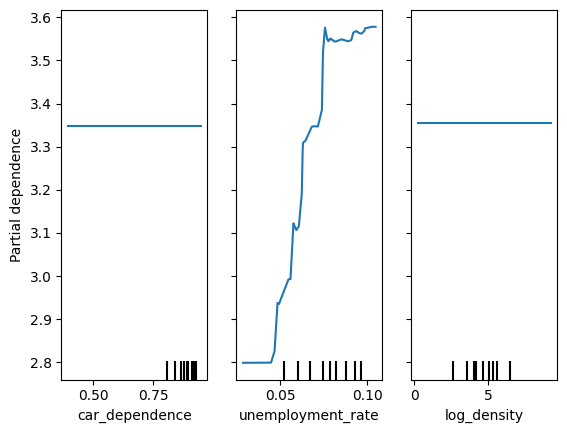

In [94]:
from sklearn.inspection import PartialDependenceDisplay

features = ["car_dependence", "unemployment_rate", "log_density"]

PartialDependenceDisplay.from_estimator(
    rf,
    X,
    features
)
plt.show()

Partial dependence plots from the Random Forest model further clarify the relationships between key predictors and mental health outcomes. Car dependence and population density both exhibit flat partial dependence curves, indicating that changes in these variables do not meaningfully affect predicted mental health outcomes when other factors are held constant. In contrast, unemployment rate shows a strong positive and nonlinear relationship with poor mental health, with predicted mental distress increasing sharply as unemployment rises. This provides further evidence that socioeconomic conditions, rather than urban form, are the primary drivers of mental health variation across states. Urban form may influence behavior (car use), but does not directly translate into mental health outcomes.

Because initial results showed that car dependence was not a strong direct predictor of mental health outcomes, the analysis was extended to examine potential mechanisms through which urban form may influence health. Prior research suggests that transportation environments affect well-being through intermediate factors such as commute time, physical activity, and environmental exposure. Therefore, I incorporate additional variables capturing these pathways to better understand how urban sprawl may indirectly impact mental health outcomes.

## Commute Time and Mental Health

In [95]:
commute = pd.read_csv(data_path + "ACSDT5Y2015.B08303-Data.csv")

In [96]:
# Clean the file
# Grab all relevant commute time columns automatically
commute_subset = commute.filter(regex="B08303_0(13|14|15|16|17)E")

# Convert all to numeric
commute_subset = commute_subset.apply(pd.to_numeric, errors="coerce")

# Total commuters
total = pd.to_numeric(commute["B08303_001E"], errors="coerce")

# Compute long commute share
commute["long_commute_share"] = commute_subset.sum(axis=1) / total

In [97]:
commute_clean = commute[["NAME", "long_commute_share"]]

merged = merged.merge(
    commute_clean,
    left_on="state_name",
    right_on="NAME",
    how="inner"
)

merged = merged.drop(columns=["NAME"], errors="ignore")

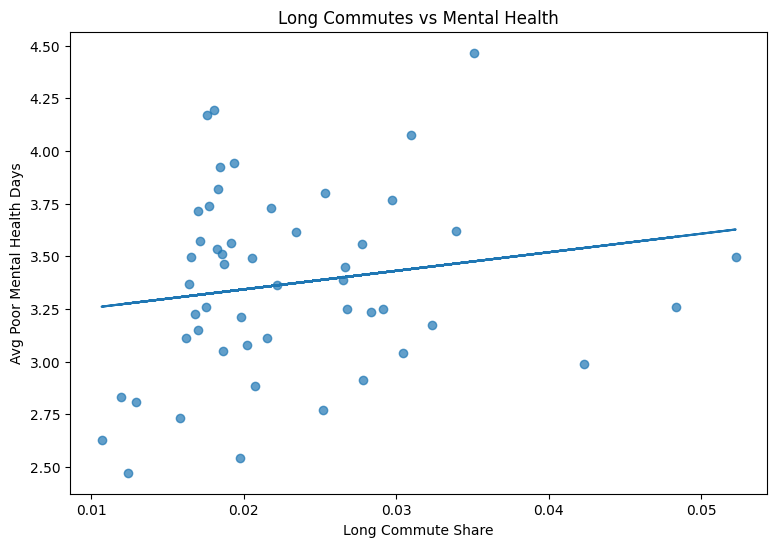

In [98]:
plt.figure(figsize=(9,6))

plt.scatter(
    merged["long_commute_share"],
    merged["avg_mental_health"],
    alpha=0.7
)

m, b = np.polyfit(
    merged["long_commute_share"],
    merged["avg_mental_health"],
    1
)

plt.plot(
    merged["long_commute_share"],
    m * merged["long_commute_share"] + b,
)

plt.xlabel("Long Commute Share")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Long Commutes vs Mental Health")

plt.show()

In [99]:
# Remove outliers using IQR
Q1 = merged["long_commute_share"].quantile(0.25)
Q3 = merged["long_commute_share"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

filtered = merged[(merged["long_commute_share"] >= lower) &
                  (merged["long_commute_share"] <= upper)]

Q1_y = merged["avg_mental_health"].quantile(0.25)
Q3_y = merged["avg_mental_health"].quantile(0.75)
IQR_y = Q3_y - Q1_y

lower_y = Q1_y - 1.5 * IQR_y
upper_y = Q3_y + 1.5 * IQR_y

filtered = filtered[(filtered["avg_mental_health"] >= lower_y) &
                    (filtered["avg_mental_health"] <= upper_y)]

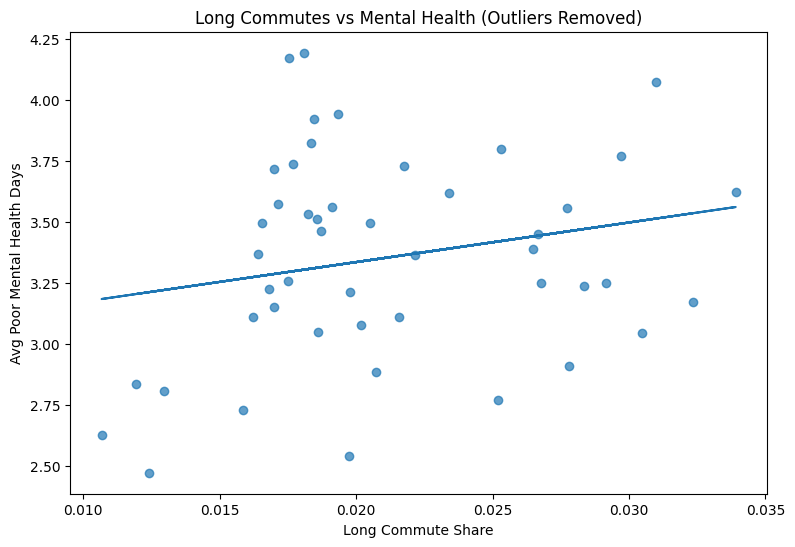

In [100]:
plt.figure(figsize=(9,6))

plt.scatter(
    filtered["long_commute_share"],
    filtered["avg_mental_health"],
    alpha=0.7
)

m, b = np.polyfit(
    filtered["long_commute_share"],
    filtered["avg_mental_health"],
    1
)

plt.plot(
    filtered["long_commute_share"],
    m * filtered["long_commute_share"] + b
)

plt.xlabel("Long Commute Share")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Long Commutes vs Mental Health (Outliers Removed)")

plt.show()

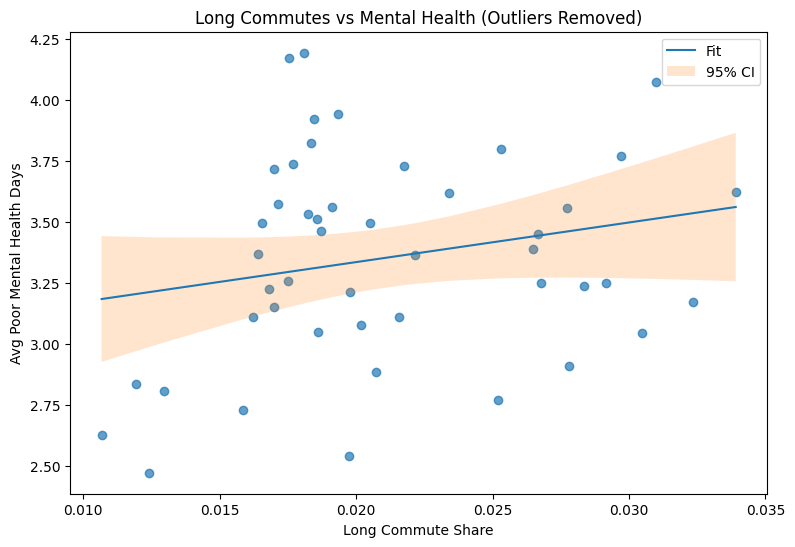

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = filtered["long_commute_share"].values
y = filtered["avg_mental_health"].values

plt.figure(figsize=(9,6))

# Scatter
plt.scatter(x, y, alpha=0.7)

# Fit line
m, b = np.polyfit(x, y, 1)

# Predicted values
y_pred = m * x + b

# Sort for clean line/CI plotting
order = np.argsort(x)
x_sorted = x[order]
y_pred_sorted = y_pred[order]

# --- Confidence Interval ---
n = len(x)
mean_x = np.mean(x)
t_val = stats.t.ppf(0.975, df=n-2)  # 95% CI

# Standard error
residuals = y - y_pred
s_err = np.sqrt(np.sum(residuals**2) / (n - 2))

ci = t_val * s_err * np.sqrt(
    1/n + (x_sorted - mean_x)**2 / np.sum((x - mean_x)**2)
)

# Plot regression line
plt.plot(x_sorted, y_pred_sorted, label="Fit")

# Plot CI band
plt.fill_between(
    x_sorted,
    y_pred_sorted - ci,
    y_pred_sorted + ci,
    alpha=0.2,
    label="95% CI"
)

plt.xlabel("Long Commute Share")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Long Commutes vs Mental Health (Outliers Removed)")
plt.legend()

plt.show()

In [102]:
X = merged[
    [
        "car_dependence",
        "long_commute_share",
        "median_income",
        "pct_bachelors_or_higher",
        "unemployment_rate"
    ]
]

y = merged["avg_mental_health"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     17.44
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.42e-09
Time:                        02:17:18   Log-Likelihood:                -2.2343
No. Observations:                  51   AIC:                             16.47
Df Residuals:                      45   BIC:                             28.06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

The results indicate that commuting behavior plays a significant role in explaining mental health outcomes. Specifically, the share of individuals experiencing long commutes is positively and statistically significantly associated with worse mental health, even after controlling for income, education, and unemployment. In contrast, overall car dependence is not a significant predictor once these factors are accounted for. This suggests that the impact of urban form on mental health may operate less through general reliance on cars and more through the lived consequences of that reliance, particularly longer commute times. These findings highlight commuting burden as a key mechanism linking urban structure to health outcomes.

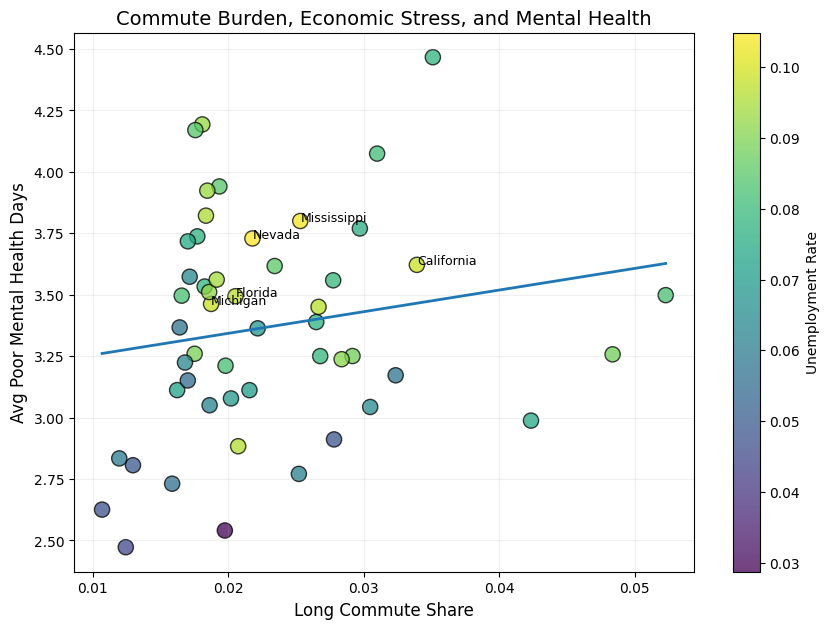

In [103]:
merged["commute_x_unemp"] = merged["long_commute_share"] * merged["unemployment_rate"]

plt.figure(figsize=(10,7))

# Scatter
sc = plt.scatter(
    merged["long_commute_share"],
    merged["avg_mental_health"],
    c=merged["unemployment_rate"],
    s=120,
    alpha=0.75,
    edgecolor="black"
)

# Regression line
m, b = np.polyfit(
    merged["long_commute_share"],
    merged["avg_mental_health"],
    1
)

x_vals = np.linspace(
    merged["long_commute_share"].min(),
    merged["long_commute_share"].max(),
    100
)

plt.plot(x_vals, m * x_vals + b, linewidth=2)

# Highlight high unemployment states (top ~5)
high_unemp = merged.nlargest(5, "unemployment_rate")

for _, row in high_unemp.iterrows():
    plt.text(
        row["long_commute_share"],
        row["avg_mental_health"],
        row["state_name"],
        fontsize=9
    )

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Unemployment Rate")

# Labels
plt.xlabel("Long Commute Share", fontsize=12)
plt.ylabel("Avg Poor Mental Health Days", fontsize=12)
plt.title("Commute Burden, Economic Stress, and Mental Health", fontsize=14)

plt.grid(alpha=0.2)

plt.show()

The figure highlights a positive relationship between the share of long commuters and poor mental health outcomes, reinforcing the idea that longer commute times are associated with increased mental health strain. This relationship becomes more pronounced when accounting for economic stress, as states with higher unemployment rates tend to cluster at higher levels of poor mental health for similar commute burdens. In contrast, states with lower unemployment appear to experience relatively better mental health even at comparable commute levels. This suggests that the negative effects of long commutes may be amplified under conditions of economic vulnerability, supporting the hypothesis that urban sprawl impacts health not only directly through commuting burden but also through its interaction with broader socioeconomic stressors.

In [104]:
# Remove Outliers
# Copy dataset
filtered = merged.copy()

# Define variables to clean
cols = ["long_commute_share", "avg_mental_health"]

# Remove outliers using IQR
for col in cols:
    Q1 = filtered[col].quantile(0.25)
    Q3 = filtered[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    filtered = filtered[(filtered[col] >= lower) & (filtered[col] <= upper)]

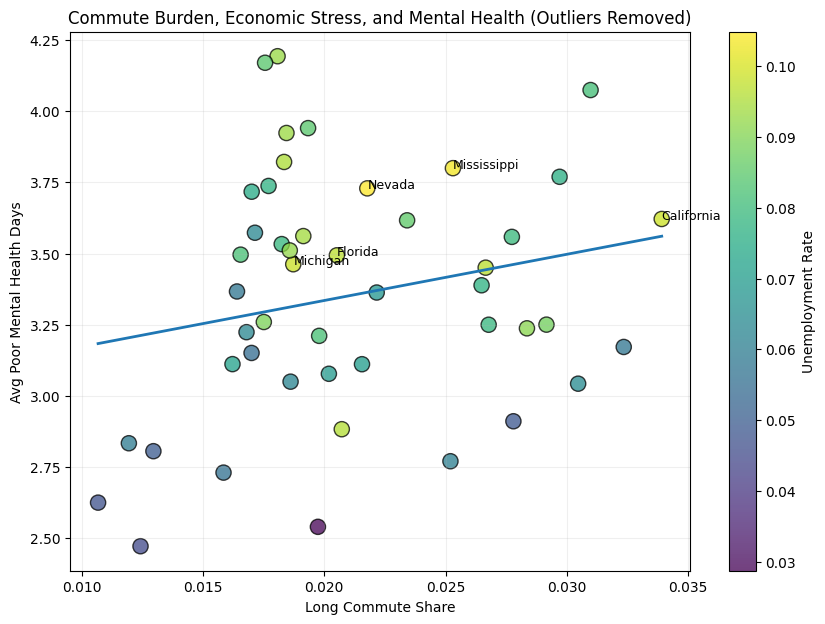

In [105]:
# Plot without outliers
plt.figure(figsize=(10,7))

sc = plt.scatter(
    filtered["long_commute_share"],
    filtered["avg_mental_health"],
    c=filtered["unemployment_rate"],
    s=120,
    alpha=0.75,
    edgecolor="black"
)

# Regression line
m, b = np.polyfit(
    filtered["long_commute_share"],
    filtered["avg_mental_health"],
    1
)

x_vals = np.linspace(
    filtered["long_commute_share"].min(),
    filtered["long_commute_share"].max(),
    100
)

plt.plot(x_vals, m * x_vals + b, linewidth=2)

# Label highest unemployment states (top 5)
high_unemp = filtered.nlargest(5, "unemployment_rate")

for _, row in high_unemp.iterrows():
    plt.text(
        row["long_commute_share"],
        row["avg_mental_health"],
        row["state_name"],
        fontsize=9
    )

cbar = plt.colorbar(sc)
cbar.set_label("Unemployment Rate")

plt.xlabel("Long Commute Share")
plt.ylabel("Avg Poor Mental Health Days")
plt.title("Commute Burden, Economic Stress, and Mental Health (Outliers Removed)")

plt.grid(alpha=0.2)
plt.show()

In [106]:
X = filtered[
    ["car_dependence", "long_commute_share",
     "median_income", "pct_bachelors_or_higher", "unemployment_rate"]
]

y = filtered["avg_mental_health"]

X = sm.add_constant(X)

model_filtered = sm.OLS(y, X).fit()
print(model_filtered.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     16.01
Date:                Sun, 10 May 2026   Prob (F-statistic):           9.73e-09
Time:                        02:17:29   Log-Likelihood:               -0.17208
No. Observations:                  47   AIC:                             12.34
Df Residuals:                      41   BIC:                             23.45
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

After removing outliers, a positive relationship emerges between long commute share and poor mental health outcomes, suggesting that commuting burden is consistently associated with increased mental health strain across states. This relationship appears to be further shaped by economic conditions: states with higher unemployment rates tend to cluster at higher levels of poor mental health even at similar commute levels, indicating that economic stress amplifies the negative effects of long commutes. Notably, states such as Mississippi and Nevada exhibit both high unemployment and relatively poor mental health outcomes, while higher-density, higher-income states like California show elevated commute burdens but comparatively moderated mental health impacts. Overall, these results support the interpretation that urban sprawl affects mental health not directly, but through lived experiences like commuting, with socioeconomic context playing a critical amplifying role. This suggests that policies targeting commute reduction, such as improved transit access or more compact urban design, may yield mental health benefits, particularly in economically vulnerable regions.

## Structural Model of Transportation, Socioeconomic Factors, and Mental Health

In [107]:
import statsmodels.api as sm

X = merged[
    [
        "drive_alone_share",
        "public_transit_share",
        "long_commute_share",
        "median_income",
        "pct_bachelors_or_higher",
        "unemployment_rate"
    ]
]

y = merged["avg_mental_health"]

X = sm.add_constant(X)

model_structural = sm.OLS(y, X).fit()

print(model_structural.summary())

                            OLS Regression Results                            
Dep. Variable:      avg_mental_health   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     14.27
Date:                Sun, 10 May 2026   Prob (F-statistic):           5.99e-09
Time:                        02:17:45   Log-Likelihood:                -2.1687
No. Observations:                  51   AIC:                             18.34
Df Residuals:                      44   BIC:                             31.86
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

To more directly align the empirical analysis with the proposed framework, I estimate a multivariate regression model in which mental health outcomes are explained by transportation patterns and socioeconomic factors. Specifically, I include measures of car-based commuting, public transit usage, income, education, and unemployment. This specification allows for a more structured test of how transportation environments and economic conditions jointly relate to mental health outcomes. In extended specifications, I also incorporate long commute share to capture the lived experience of transportation burden, which prior analysis suggests may serve as a key mechanism linking urban form to health.

In [108]:
from sklearn.preprocessing import StandardScaler

X_vars = [
    "drive_alone_share",
    "public_transit_share",
    "long_commute_share",
    "median_income",
    "pct_bachelors_or_higher",
    "unemployment_rate"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(merged[X_vars])
X_scaled = pd.DataFrame(X_scaled, columns=X_vars)

y_scaled = StandardScaler().fit_transform(
    merged[["avg_mental_health"]]
).flatten()

X_scaled = sm.add_constant(X_scaled)

model_std = sm.OLS(y_scaled, X_scaled).fit()

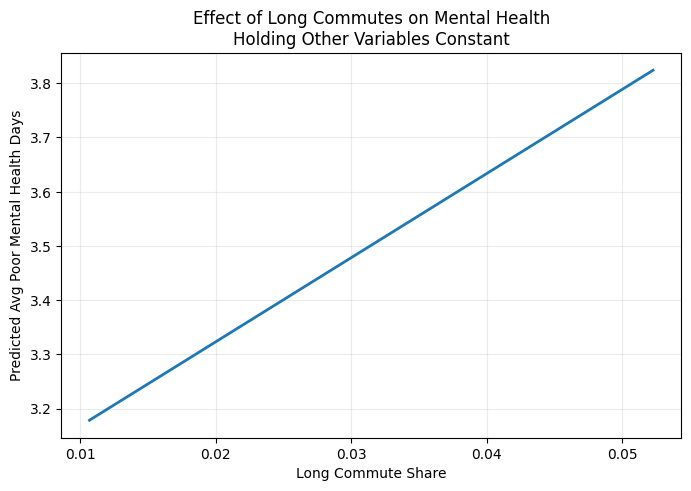

In [109]:
# Hold other variables at their mean
means = merged[X_vars].mean()

x_vals = np.linspace(
    merged["long_commute_share"].min(),
    merged["long_commute_share"].max(),
    100
)

pred_df = pd.DataFrame(
    {col: means[col] for col in X_vars},
    index=range(100)
)

pred_df["long_commute_share"] = x_vals

# IMPORTANT: force constant column
pred_df = sm.add_constant(pred_df, has_constant="add")

# Make sure columns match the model exactly
pred_df = pred_df[model_structural.model.exog_names]

y_pred = model_structural.predict(pred_df)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_pred, linewidth=2)

plt.xlabel("Long Commute Share")
plt.ylabel("Predicted Avg Poor Mental Health Days")
plt.title("Effect of Long Commutes on Mental Health\nHolding Other Variables Constant")
plt.grid(alpha=0.25)
plt.show()

The partial effect plot shows a clear positive relationship between long commute share and predicted mental health burden, holding other variables constant. This suggests that longer commute times may independently contribute to worse mental health outcomes, beyond broader socioeconomic conditions. While the model is linear, the magnitude of the effect is meaningful, with increases in long commute share associated with noticeable increases in predicted poor mental health days.

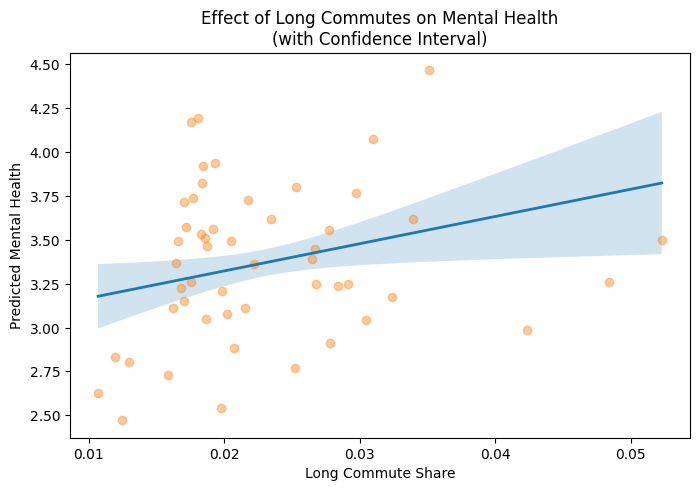

In [110]:
pred = model_structural.get_prediction(pred_df)
pred_summary = pred.summary_frame()

plt.figure(figsize=(8,5))

plt.plot(x_vals, pred_summary["mean"], linewidth=2)
plt.fill_between(
    x_vals,
    pred_summary["mean_ci_lower"],
    pred_summary["mean_ci_upper"],
    alpha=0.2
)

plt.xlabel("Long Commute Share")
plt.ylabel("Predicted Mental Health")
plt.title("Effect of Long Commutes on Mental Health\n(with Confidence Interval)")

plt.scatter(
    merged["long_commute_share"],
    merged["avg_mental_health"],
    alpha=0.4
)

plt.show()

Higher long commute shares are associated with worse mental health outcomes, even after controlling for income, education, and unemployment. The effect is meaningful in size, with higher commute burdens corresponding to roughly 0.5–0.6 additional poor mental health days. While the overall relationship is positive, the widening confidence interval at higher commute levels suggests greater uncertainty due to fewer observations. The spread of the data also indicates that commute burden is not the sole driver of mental health, but it appears to be an important mechanism linking urban structure—particularly car-dependent, sprawling environments—to health outcomes.

In [114]:
# Summary statistics table

summary_vars = {
    "avg_mental_health": "Avg Poor Mental Health Days",
    "car_dependence": "Car Dependence",
    "drive_alone_share": "Drive Alone Share",
    "public_transit_share": "Public Transit Share",
    "long_commute_share": "Long Commute Share",
    "median_income": "Median Income ($)",
    "pct_bachelors_or_higher": "BA or Higher",
    "unemployment_rate": "Unemployment Rate",
    "population_density": "Population Density"
}

summary_table = merged[list(summary_vars.keys())].describe().T[
    ["mean", "std", "min", "max"]
]

summary_table = summary_table.rename(index=summary_vars)
summary_table = summary_table.rename(
    columns={
        "mean": "Mean",
        "std": "SD",
        "min": "Min",
        "max": "Max"
    }
)

# Optional: make rates percentages
percent_rows = [
    "Car Dependence",
    "Drive Alone Share",
    "Public Transit Share",
    "Long Commute Share",
    "BA or Higher",
    "Unemployment Rate"
]

summary_display = summary_table.copy()

for row in percent_rows:
    summary_display.loc[row] = summary_display.loc[row] * 100

summary_display = summary_display.round(2)

summary_display

,Mean,SD,Min,Max
Avg Poor Mental Health Days,3.37,0.44,2.47,4.47
Car Dependence,86.71,8.74,39.49,94.63
Drive Alone Share,77.13,8.30,33.74,85.45
Public Transit Share,3.83,6.51,0.40,37.41
Long Commute Share,2.29,0.86,1.07,5.23
Median Income ($),54636.10,9157.17,39665.00,74551.00
BA or Higher,29.51,6.06,19.16,54.58
Unemployment Rate,7.63,1.72,2.87,10.49
Population Density,402.69,1481.83,1.29,10614.49


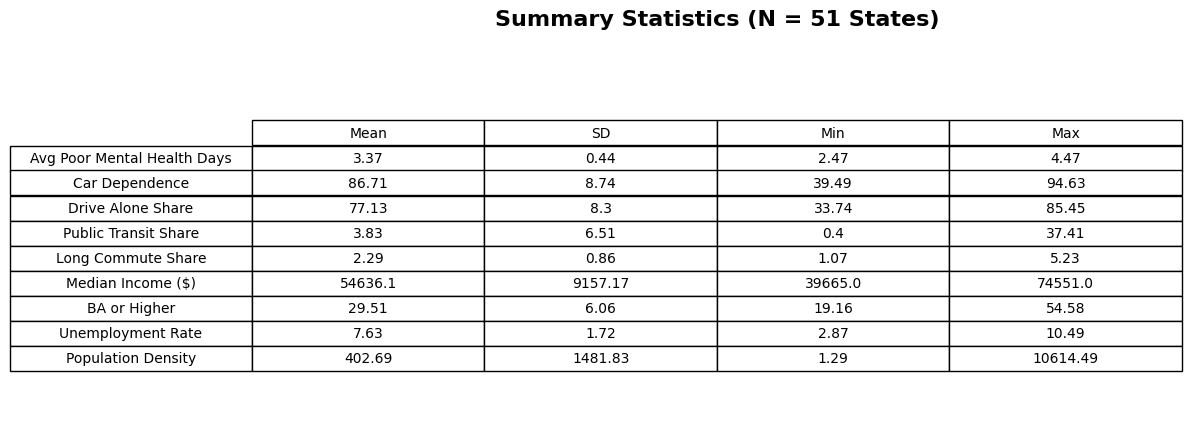

In [115]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

table = ax.table(
    cellText=summary_display.values,
    rowLabels=summary_display.index,
    colLabels=summary_display.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title(
    f"Summary Statistics (N = {len(merged)} States)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.show()

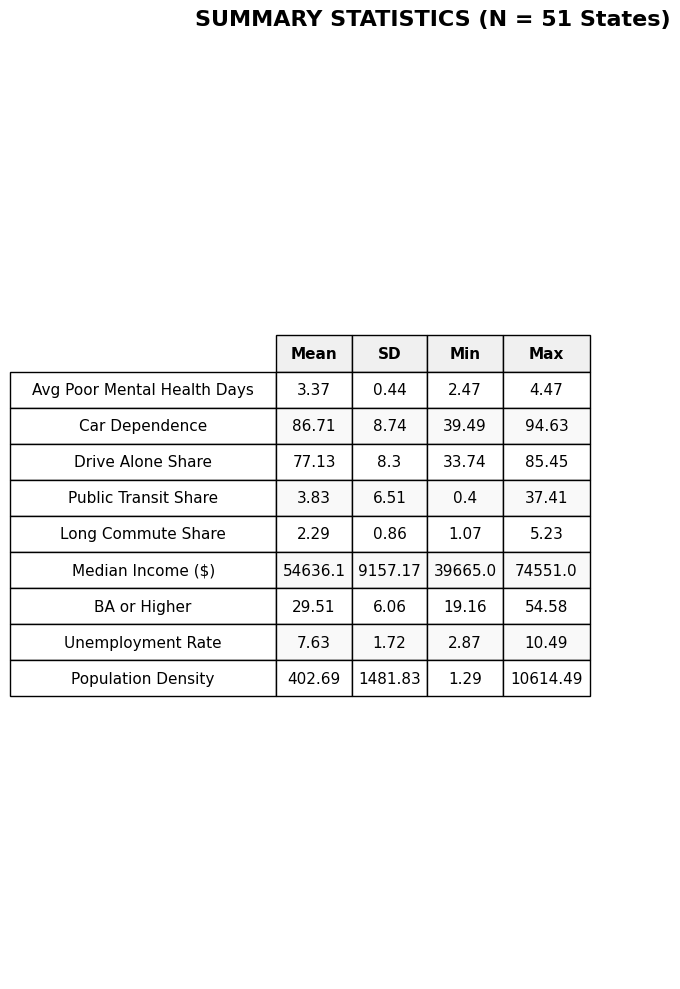

<Figure size 640x480 with 0 Axes>

In [116]:
fig, ax = plt.subplots(figsize=(6, 10))  # tall layout
ax.axis("off")

table = ax.table(
    cellText=summary_display.values,
    rowLabels=summary_display.index,
    colLabels=summary_display.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Adjust column widths
for i in range(len(summary_display.columns)):
    table.auto_set_column_width(col=i)

# Bold header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor("#f0f0f0")



# Title
plt.title(
    f"SUMMARY STATISTICS (N = {len(merged)} States)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

for i in range(1, len(summary_display) + 1):
    for j in range(len(summary_display.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()

plt.savefig("summary_stats.png", dpi=300, bbox_inches="tight")